In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import joblib
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest
import adjustText
import re

import common_data

In [3]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200
%config InlineBackend.figure_format = "retina"

In [ ]:
ROOT = common_data.DATA

In [5]:
sc_labels = pd.read_csv(common_data.SC_LABELS, index_col=0)

In [ ]:
class ComparisonInfo:
    def __init__(self, control, condition, genes, genes_to_keep):
        self.control = control
        self.condition = condition
        self.genes_raw = genes
        self.filter_genes(genes_to_keep)

    def filter_genes(self, genes_to_keep):
        filtered_degs = self.genes_raw.loc[self.genes_raw.index.isin(genes_to_keep), :].copy()
        filtered_degs = filtered_degs.loc[filtered_degs.pvalue.notna()].copy()
        # recompute FDR correction on the filtered genes:
        filtered_degs['padj'] = statsmodels.stats.multitest.fdrcorrection(filtered_degs.pvalue)[1]
        # recompute gene status based on new `padj`
        filtered_degs['sign'] = ''
        filtered_degs.loc[
            filtered_degs.padj.lt(0.05)
            & filtered_degs.log2FoldChange.gt(0),
            'sign'
        ] = f'Up in {self.condition}'
        filtered_degs.loc[
            filtered_degs.padj.lt(0.05)
            & filtered_degs.log2FoldChange.lt(0),
            'sign'
        ] = f'Up in {self.control}'
        self.genes = filtered_degs


class CellTypeInfo:
    def __init__(self, path, task_info, genes_to_keep):
        self.path = path
        self.task_info = task_info
        self.comparisons = []
        self.meta = pd.read_csv(path / 'meta.csv', index_col=0)
        self.name = self.meta.cell_type.values[0]

        self.load_comparisons(genes_to_keep)

    def load_comparisons(self, genes_to_keep):
        for run in self.path.glob('**/degs.csv'):
            self.comparisons.append(
                ComparisonInfo(
                    self.task_info.column_values[0],
                    self.task_info.column_values[0],
                    pd.read_csv(run, index_col=0),
                    genes_to_keep[self.name]
                )
            )

    @property
    def n_comparisons(self):
        return len(self.comparisons)

In [7]:
class TaskData:
    def __init__(self, task, task_info):
        self.task = task
        self.task_info = task_info
        self.info = {}

In [ ]:
data = joblib.load('20c_deg_data.joblib')

In [9]:
PADJ_CUTOFF = 0.05

In [10]:
n_degs_plot = pd.DataFrame()
n_degs = pd.DataFrame()
for task_data in data.values():
    for ct, info in task_data.info.items():
        name = task_data.task_info.pathname
        n_genes = info.comparisons[0].genes.padj.lt(PADJ_CUTOFF).sum()
        n_degs.loc[ct, name] = n_genes
        if n_genes > 0:
            n_genes = np.log10(n_genes)
        n_degs_plot.loc[ct, name] = n_genes
n_degs = n_degs.sort_index().T.sort_index()
n_degs_plot = n_degs_plot.sort_index().T.sort_index()

Text(0.5, 1.0, 'Number of DEGs')

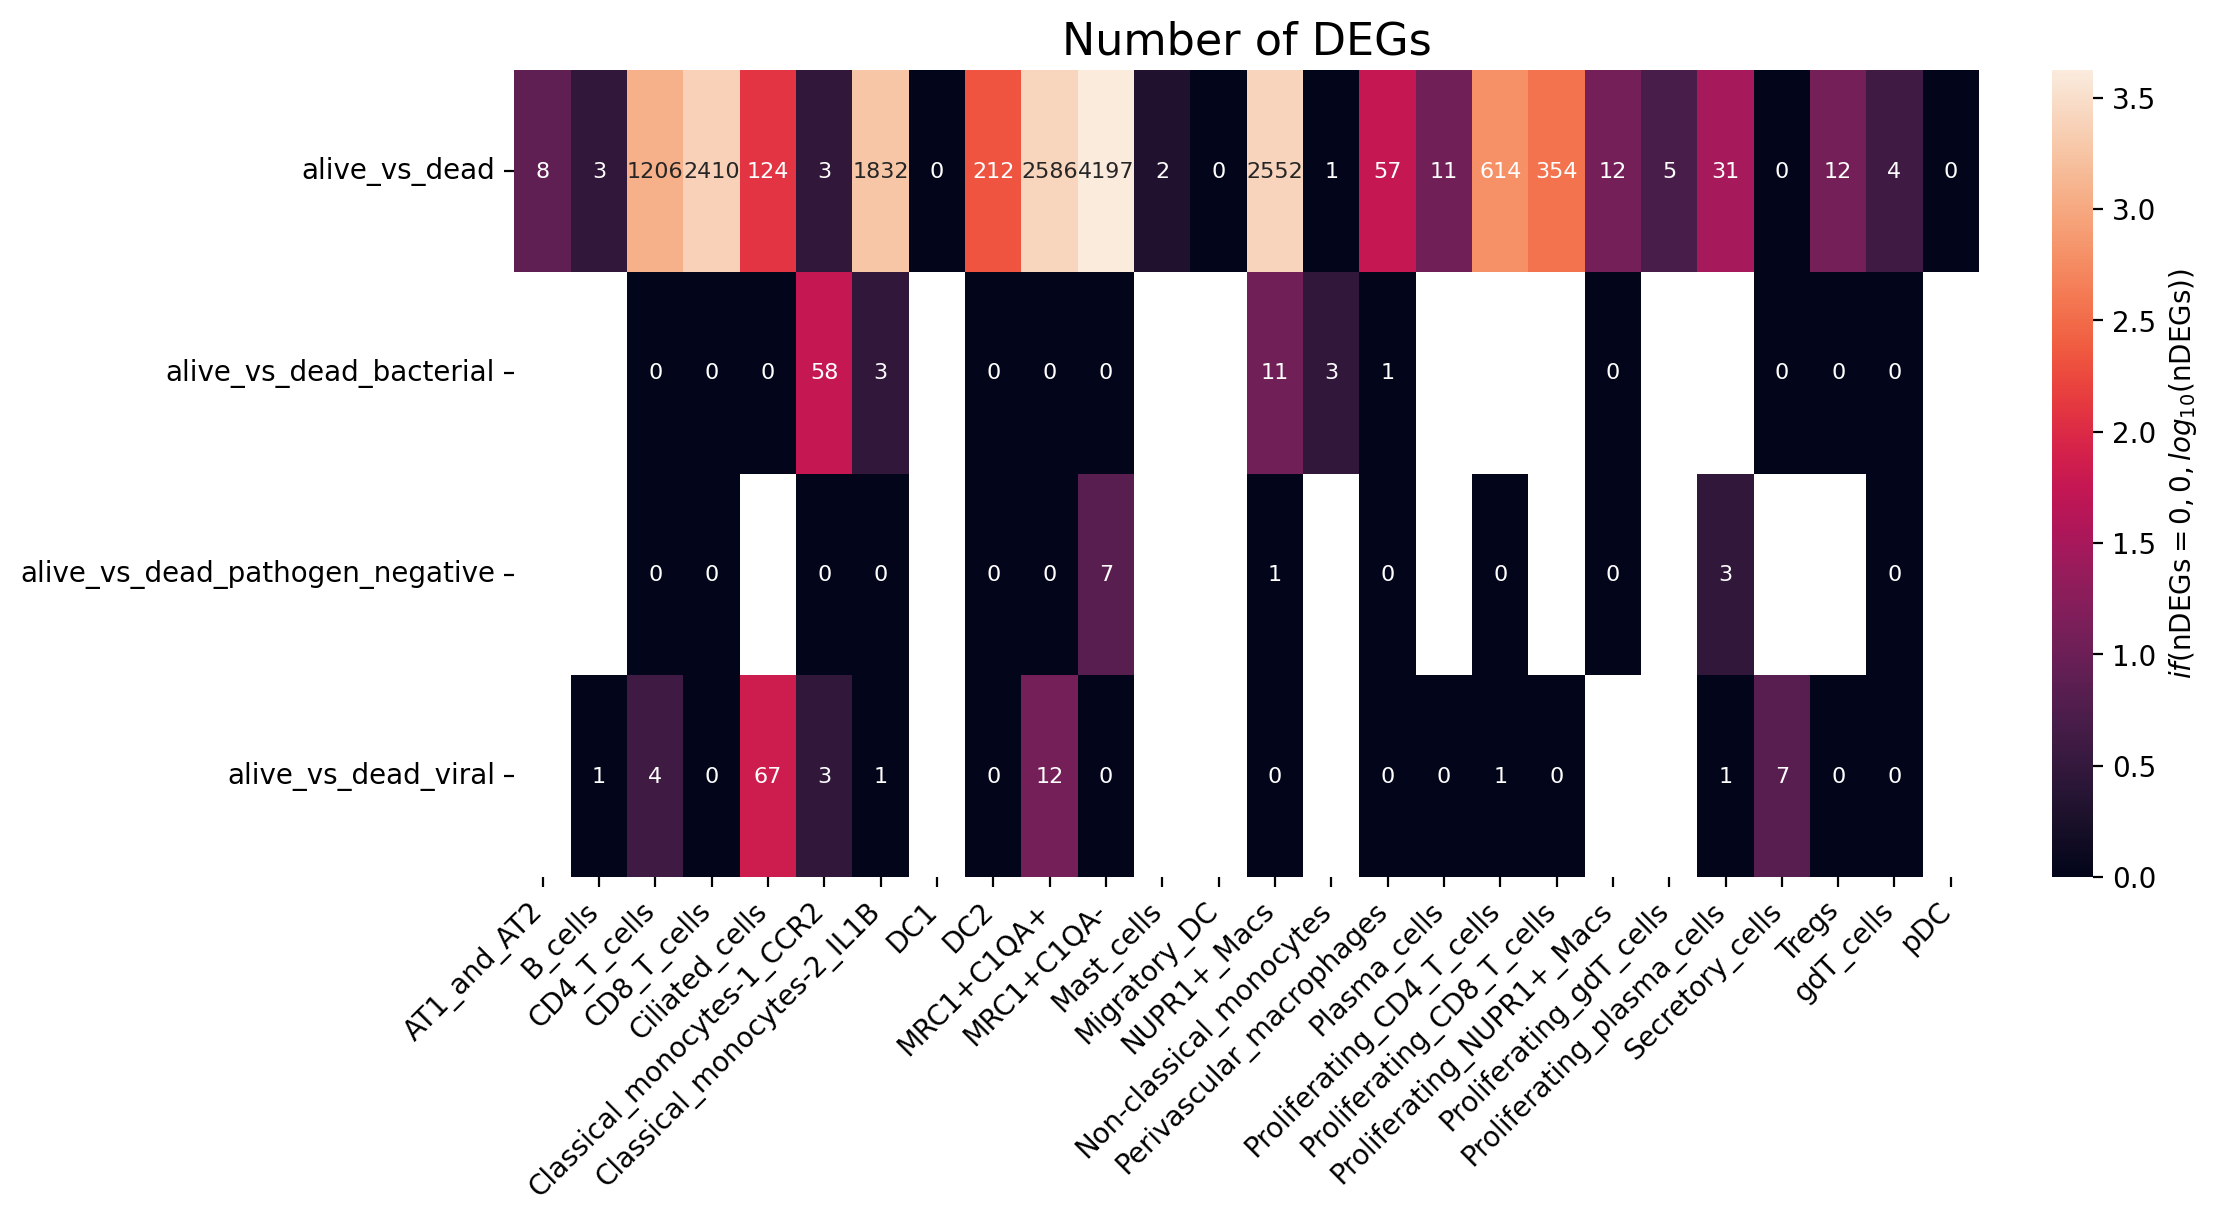

In [11]:
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.heatmap(
    n_degs_plot,
    cbar_kws=dict(
        label='$if(\mathrm{nDEGs} = 0, 0, log_{10}(\mathrm{n DEGs}))$'
    ),
    annot=n_degs,
    fmt='.0f',
    annot_kws=dict(
        size=8
    ),
    ax=ax
)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(45)
    t.set_transform(t.get_transform() + trans)
ax.set_title('Number of DEGs', size=16)

## 1. Alive vs Dead in Bacterial

In [12]:
plot_df = []
for k, info in data['alive_vs_dead_bacterial'].info.items():
    plot_df.append((
        k,
        info.comparisons[0].genes.sign.eq('Up in alive').sum(),
        info.comparisons[0].genes.sign.eq('Up in dead').sum(),
    ))
plot_df = pd.DataFrame(
    plot_df,
    columns=['cell_type', 'Up in Alive in Bacterial', 'Up in Dead in Bacterial']
)

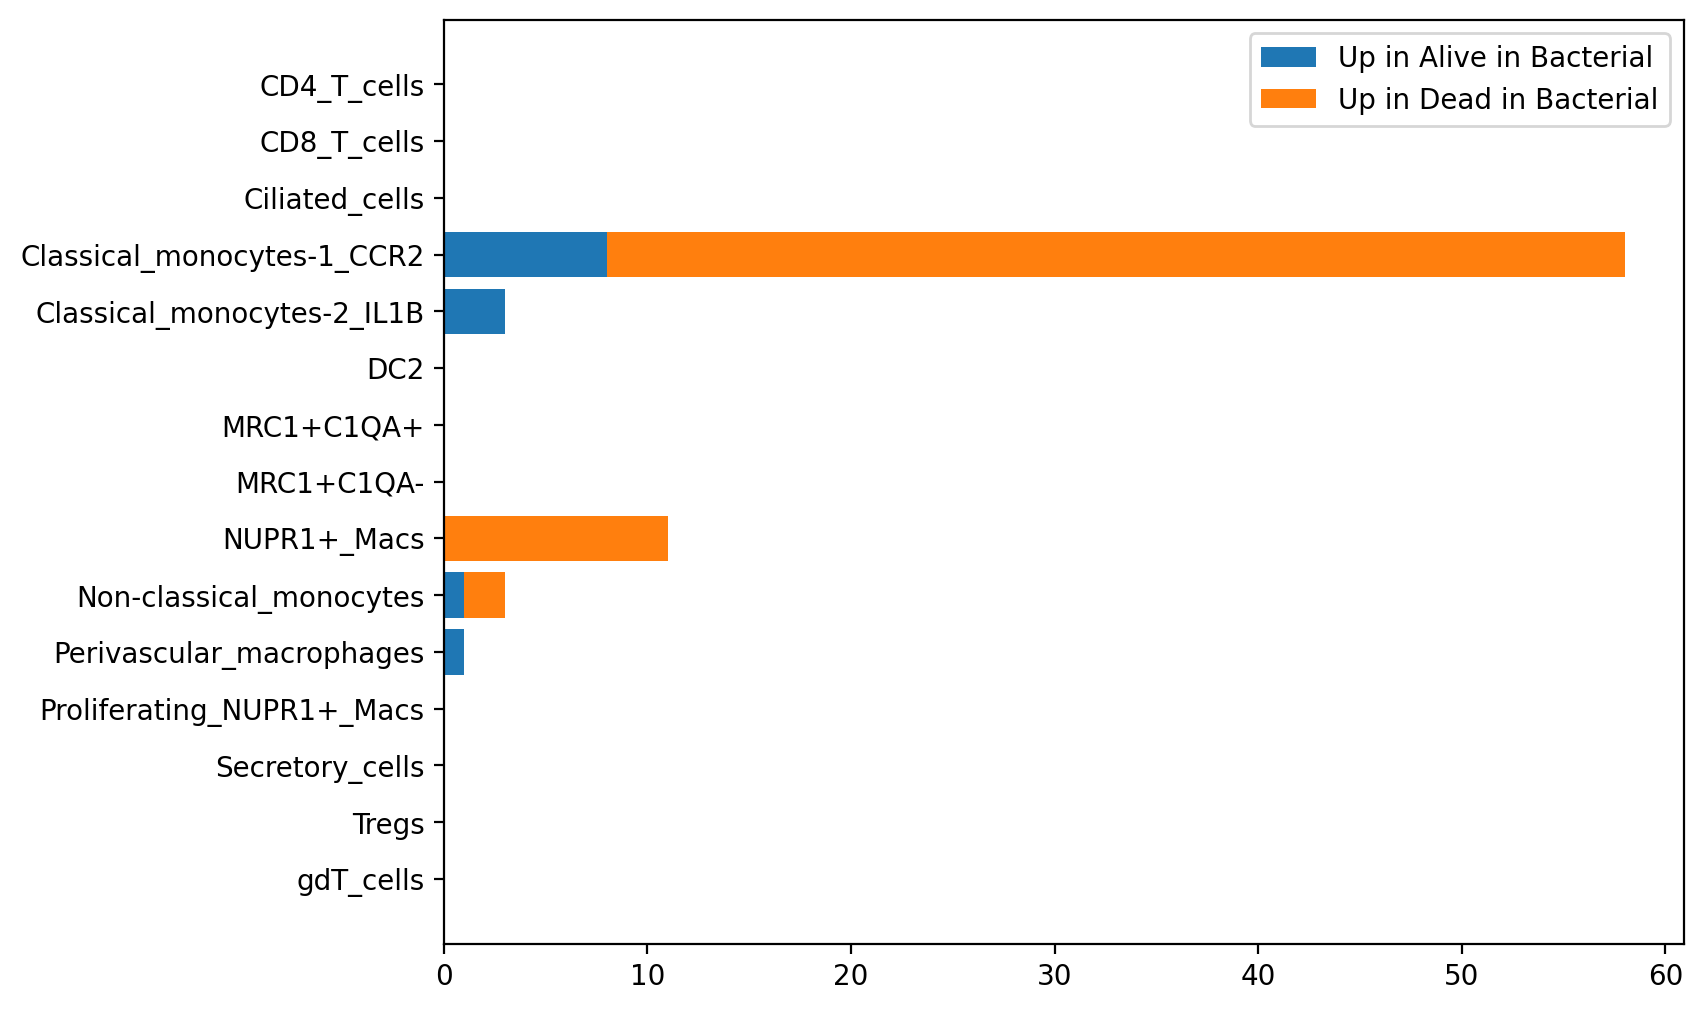

In [13]:
offset = np.zeros(plot_df.shape[0])
coords = list(range(plot_df.shape[0]))
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coords, plot_df['Up in Alive in Bacterial'], label='Up in Alive in Bacterial')
offset += plot_df['Up in Alive in Bacterial'].values
ax.barh(coords, plot_df['Up in Dead in Bacterial'], left=offset, label='Up in Dead in Bacterial')
ax.set_yticks(coords, labels=plot_df.cell_type);
ax.invert_yaxis()
ax.legend()

### Plot MA

In [14]:
def plot_ma(comp_data, cell_type, adjust=True, exclude=None):
    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
    df = comp_data.genes.copy()
    if exclude:
        df = df.loc[~df.index.isin(exclude)].copy()
    # An attempt to plot all genes, not just selected higher-expression:

    # df = df.merge(
    #     comp_data.genes[['sign', 'padj']],
    #     left_index=True,
    #     right_index=True,
    #     how='left',
    #     suffixes=('_blah', '')
    # )
    df['color'] = '#cccccc'
    control_idx = df.padj.lt(PADJ_CUTOFF) & df.log2FoldChange.lt(0)
    condition_idx = df.padj.lt(PADJ_CUTOFF) & df.log2FoldChange.gt(0)
    df = df.sort_values('padj', ascending=False)
    df.loc[control_idx, 'color'] = '#6bbbdd'
    df.loc[condition_idx, 'color'] = '#dd6b6f'
    ax.scatter(df.baseMean, df.log2FoldChange, c=df.color, s=15)
    ax.set_xlabel('average expression', size=14)
    ax.set_ylabel('$\log_2(\mathrm{fold\ change})$', size=14)
    ax.set_xscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = []
    legend.append(mpl.lines.Line2D(
        [0], [0],
        label=f'Up in {comp_data.control} ({control_idx.sum()})',
        color='#ffffffff',
        markerfacecolor='#6bbbdd',
        marker='o',
        markersize=8
    ))
    legend.append(mpl.lines.Line2D(
        [0], [0],
        label=f'Up in {comp_data.condition} ({condition_idx.sum()})',
        color='#ffffffff',
        markerfacecolor='#dd6b6f',
        marker='o',
        markersize=8
    ))
    legend.append(mpl.lines.Line2D(
        [0], [0],
        label=f'not significant ({df.shape[0] - control_idx.sum() - condition_idx.sum()})',
        color='#ffffffff',
        markerfacecolor='#cccccc',
        marker='o',
        markersize=8
    ))
    ax.set_title(cell_type, size=16)
    texts = []
    for gene, r in df.loc[df.padj.lt(PADJ_CUTOFF)].sort_values('log2FoldChange').head(10).iterrows():
        if r.log2FoldChange > 0:
            break
        texts.append(
            ax.text(r.baseMean, r.log2FoldChange, gene, ha='center', va='center', fontstyle='italic')
        )
    for gene, r in df.loc[df.padj.lt(PADJ_CUTOFF)].sort_values('log2FoldChange').tail(10).iterrows():
        if r.log2FoldChange < 0:
            continue
        texts.append(
            ax.text(r.baseMean, r.log2FoldChange, gene, ha='center', va='center', fontstyle='italic')
        )
    if adjust:
        adjustText.adjust_text(
            texts,
            objects=ax.collections[0],
            arrowprops=dict(arrowstyle="-", color='#666666', lw=0.5),
            force_static=(0.2, 0.5),
            expand=(1.2, 1.5),
            iter_lim=50,
        )
    ax.legend(handles=legend, fontsize=10, frameon=False, handletextpad=-0.3);
    # ax.set_xlim(0.1)
    return ax

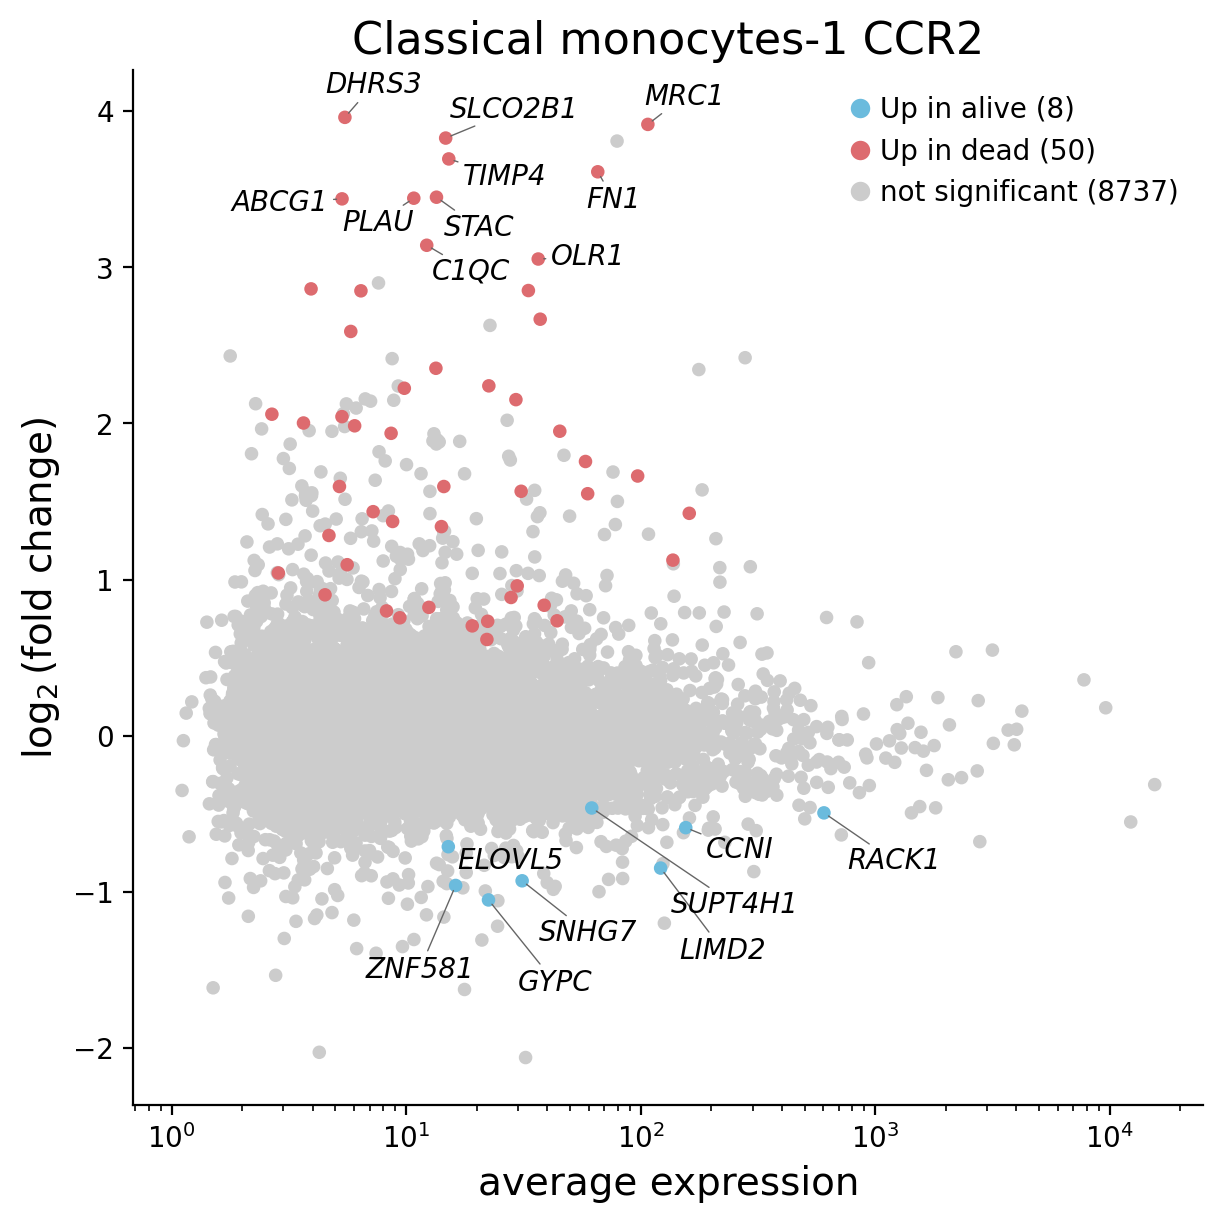

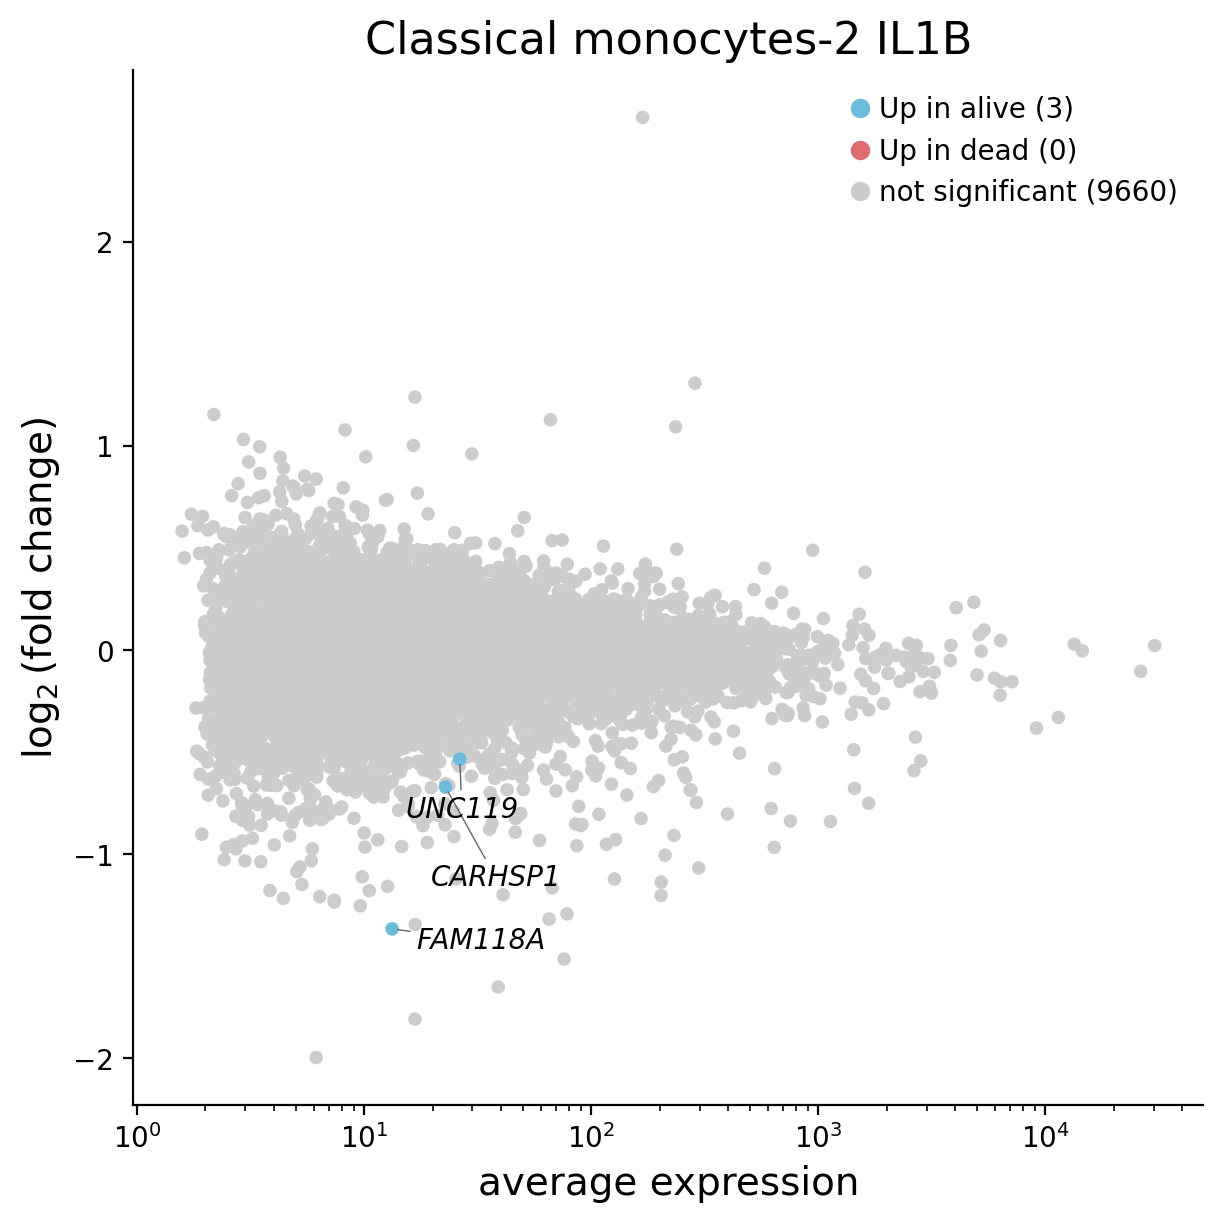

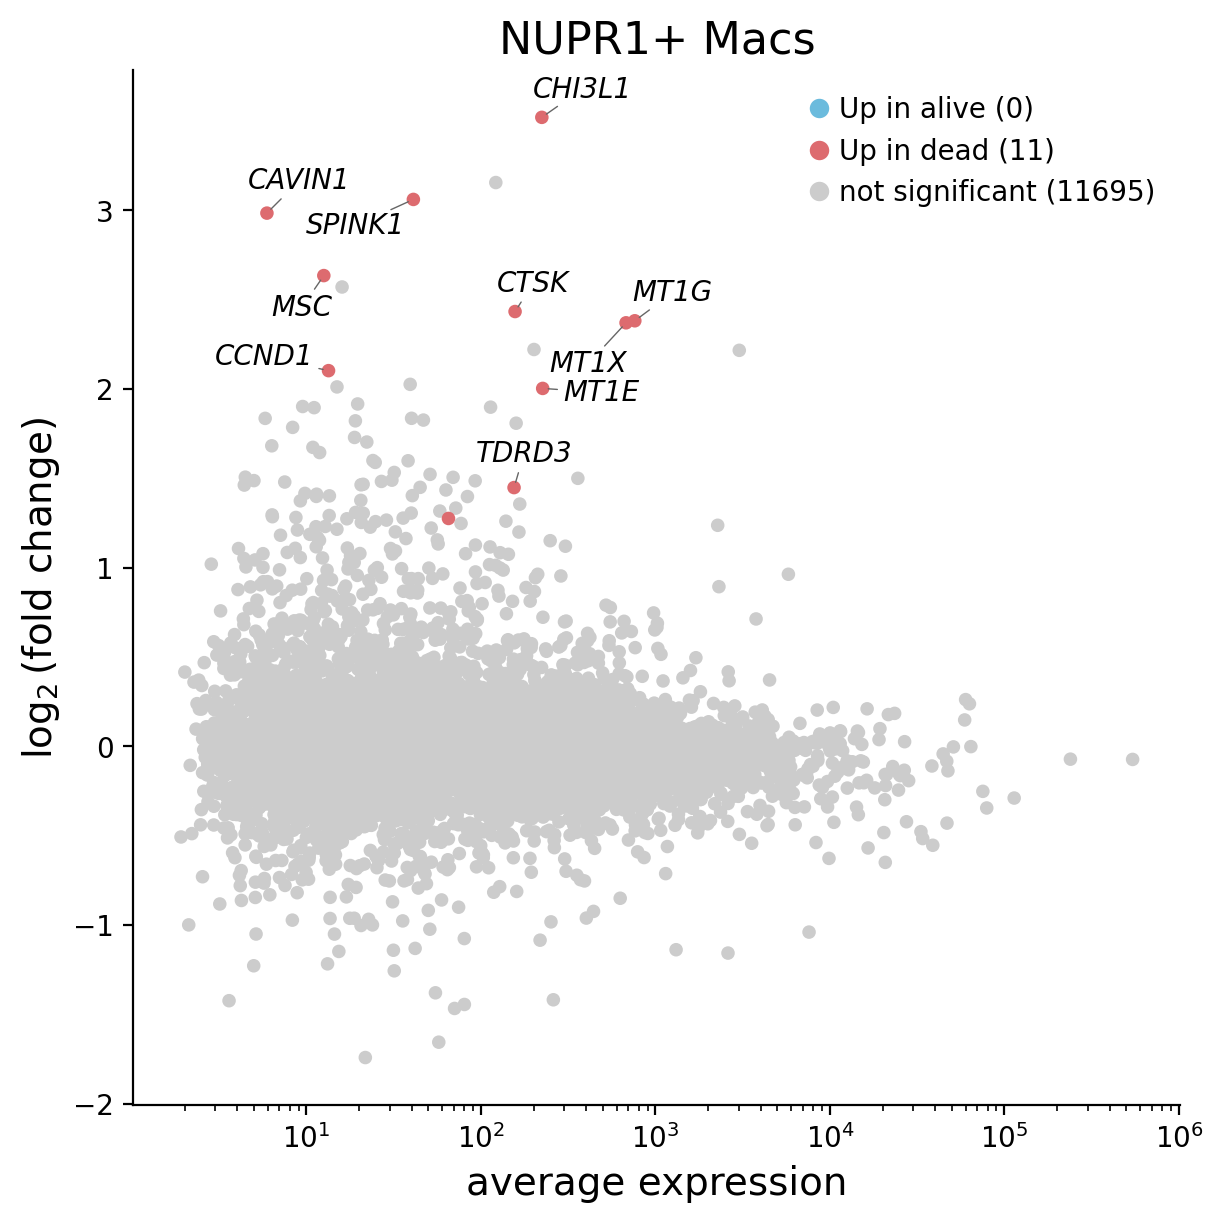

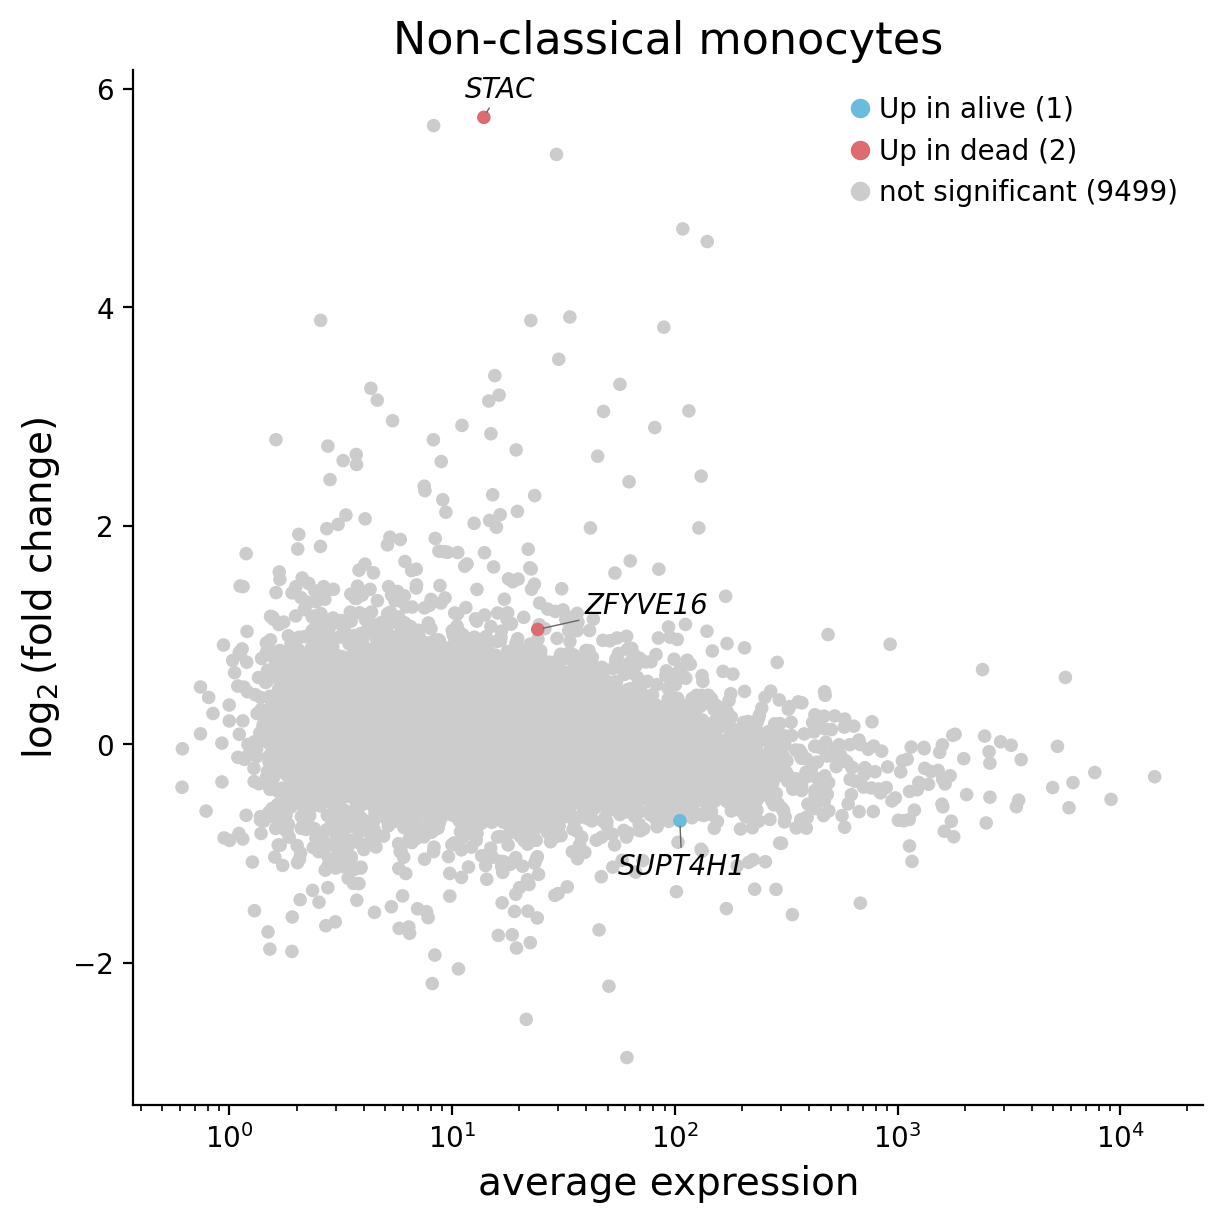

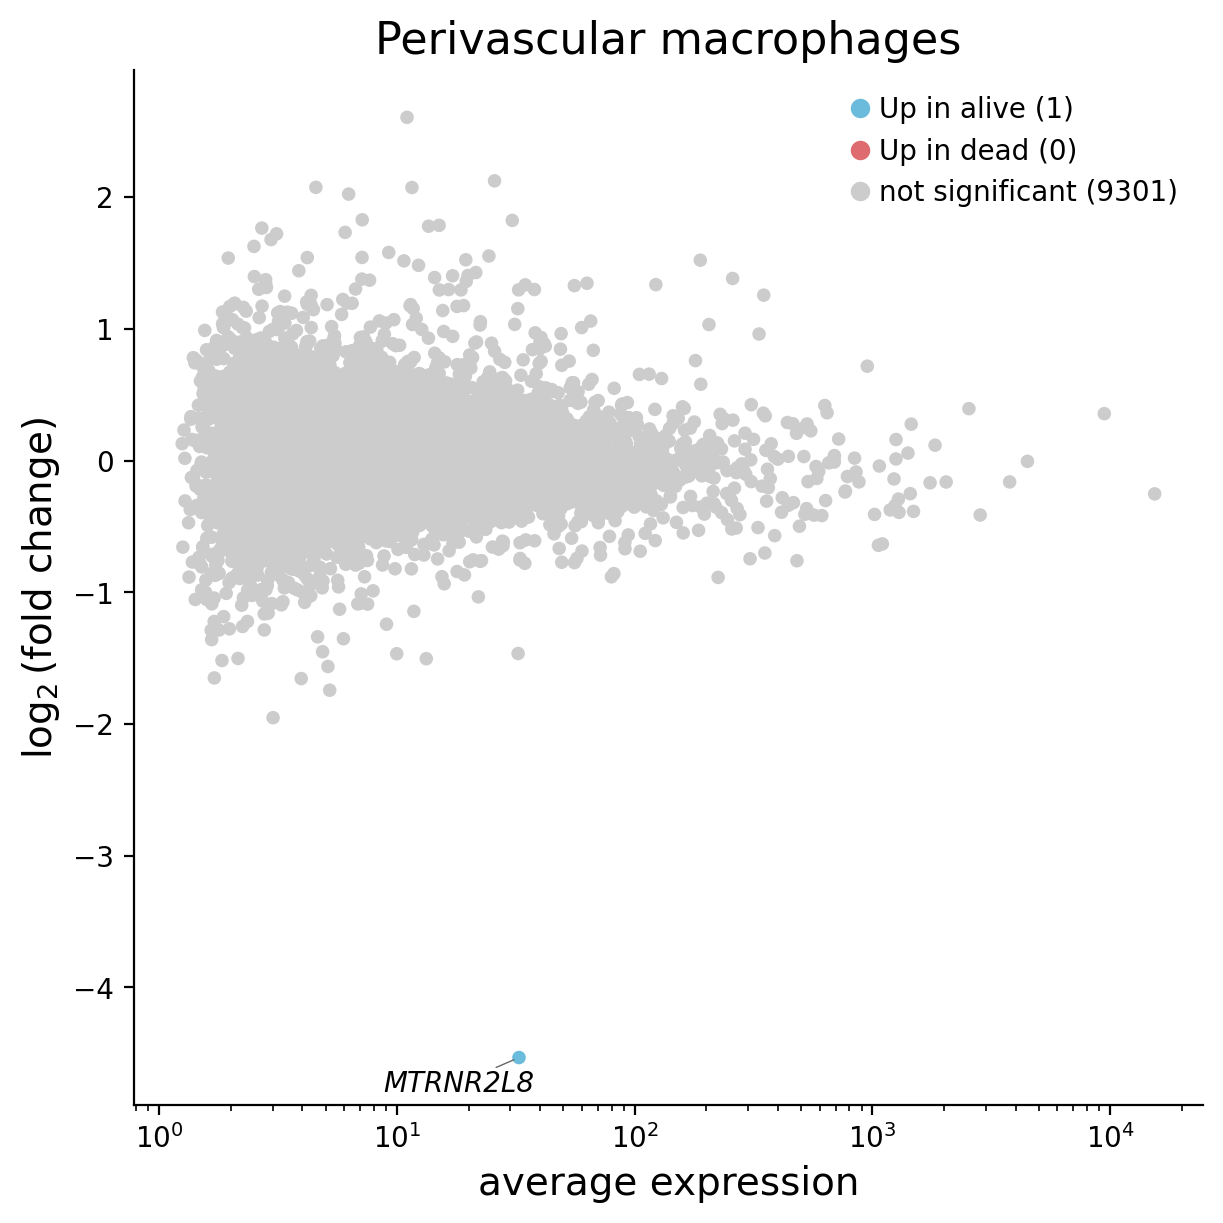

In [15]:
for ct in data['alive_vs_dead_bacterial'].info.values():
    if ct.comparisons[0].genes.sign.ne('').sum() < 1:
        continue
    plot_ma(
        ct.comparisons[0],
        ct.name,
        # adjust=False
    )
    plt.show()

## 2. Alive vs Dead in Viral

In [16]:
plot_df = []
for k, info in data['alive_vs_dead_viral'].info.items():
    plot_df.append((
        k,
        info.comparisons[0].genes.sign.eq('Up in alive').sum(),
        info.comparisons[0].genes.sign.eq('Up in dead').sum(),
    ))
plot_df = pd.DataFrame(
    plot_df,
    columns=['cell_type', 'Up in Alive in Viral', 'Up in Dead in Viral']
)

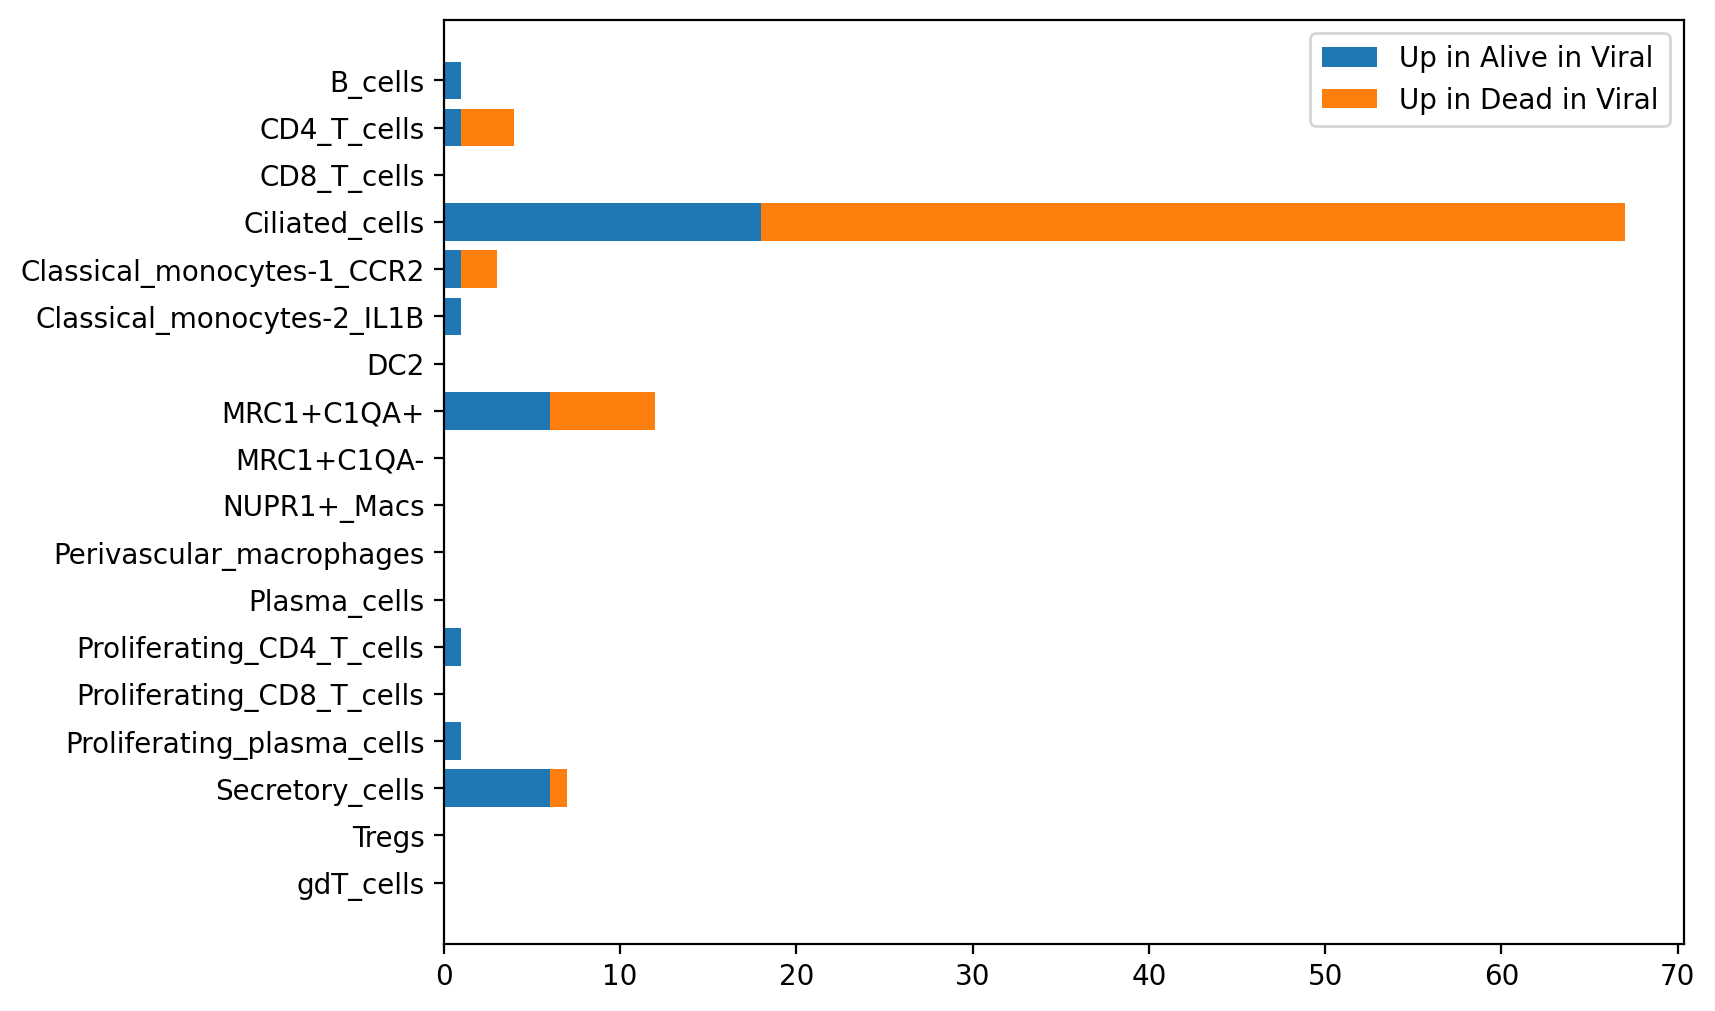

In [17]:
offset = np.zeros(plot_df.shape[0])
coords = list(range(plot_df.shape[0]))
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coords, plot_df['Up in Alive in Viral'], label='Up in Alive in Viral')
offset += plot_df['Up in Alive in Viral'].values
ax.barh(coords, plot_df['Up in Dead in Viral'], left=offset, label='Up in Dead in Viral')
ax.set_yticks(coords, labels=plot_df.cell_type);
ax.invert_yaxis()
ax.legend()

### Plot MA

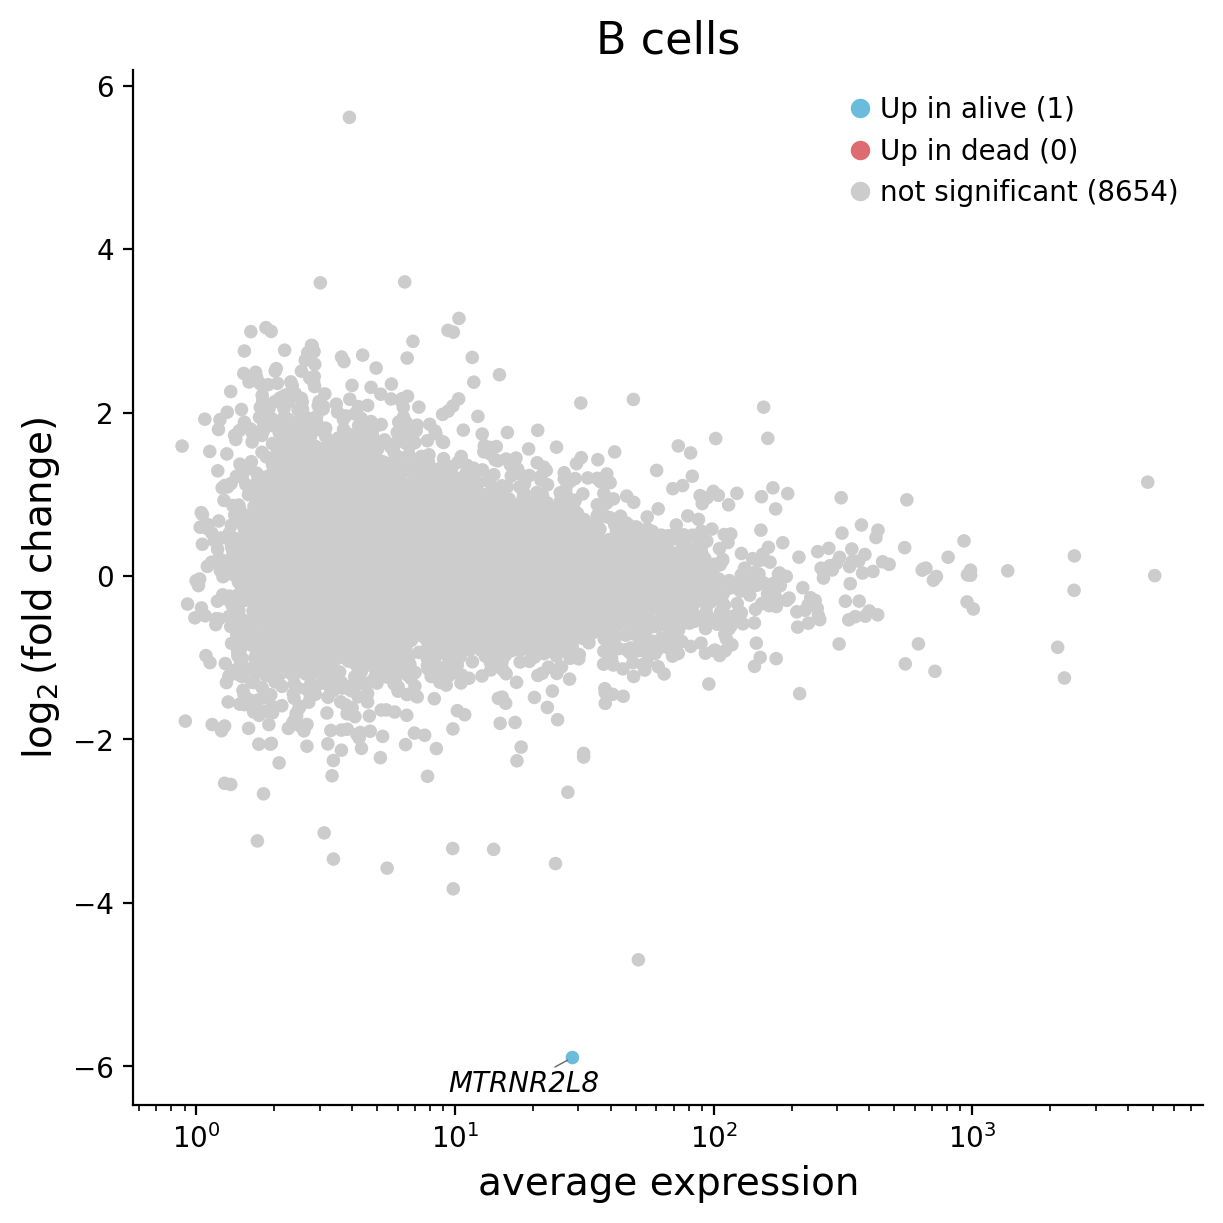

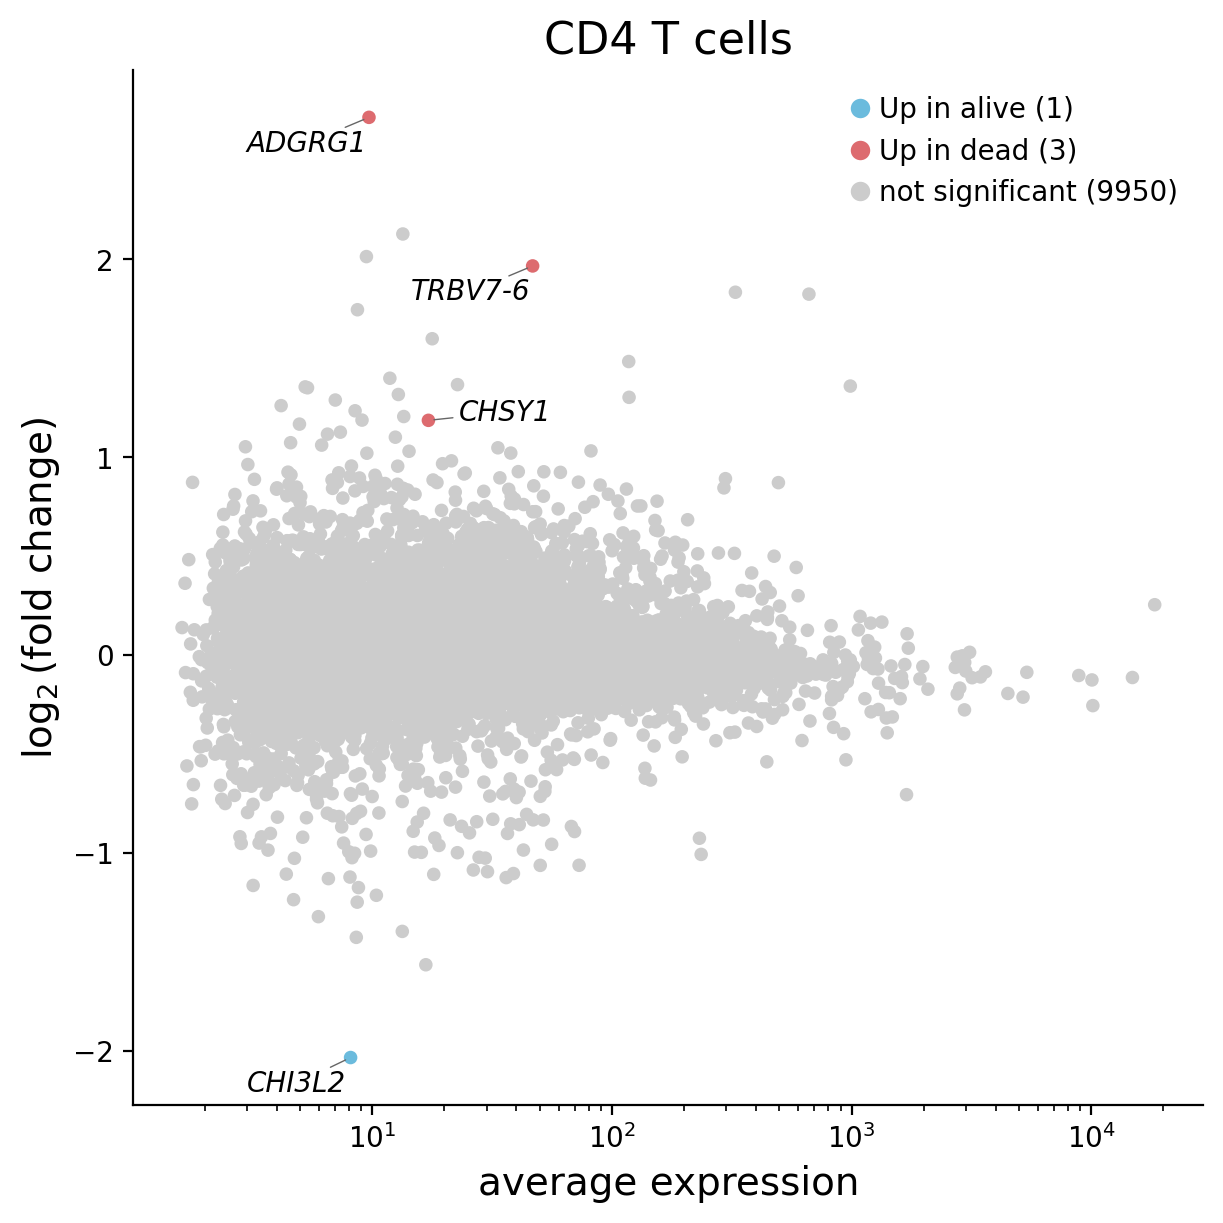

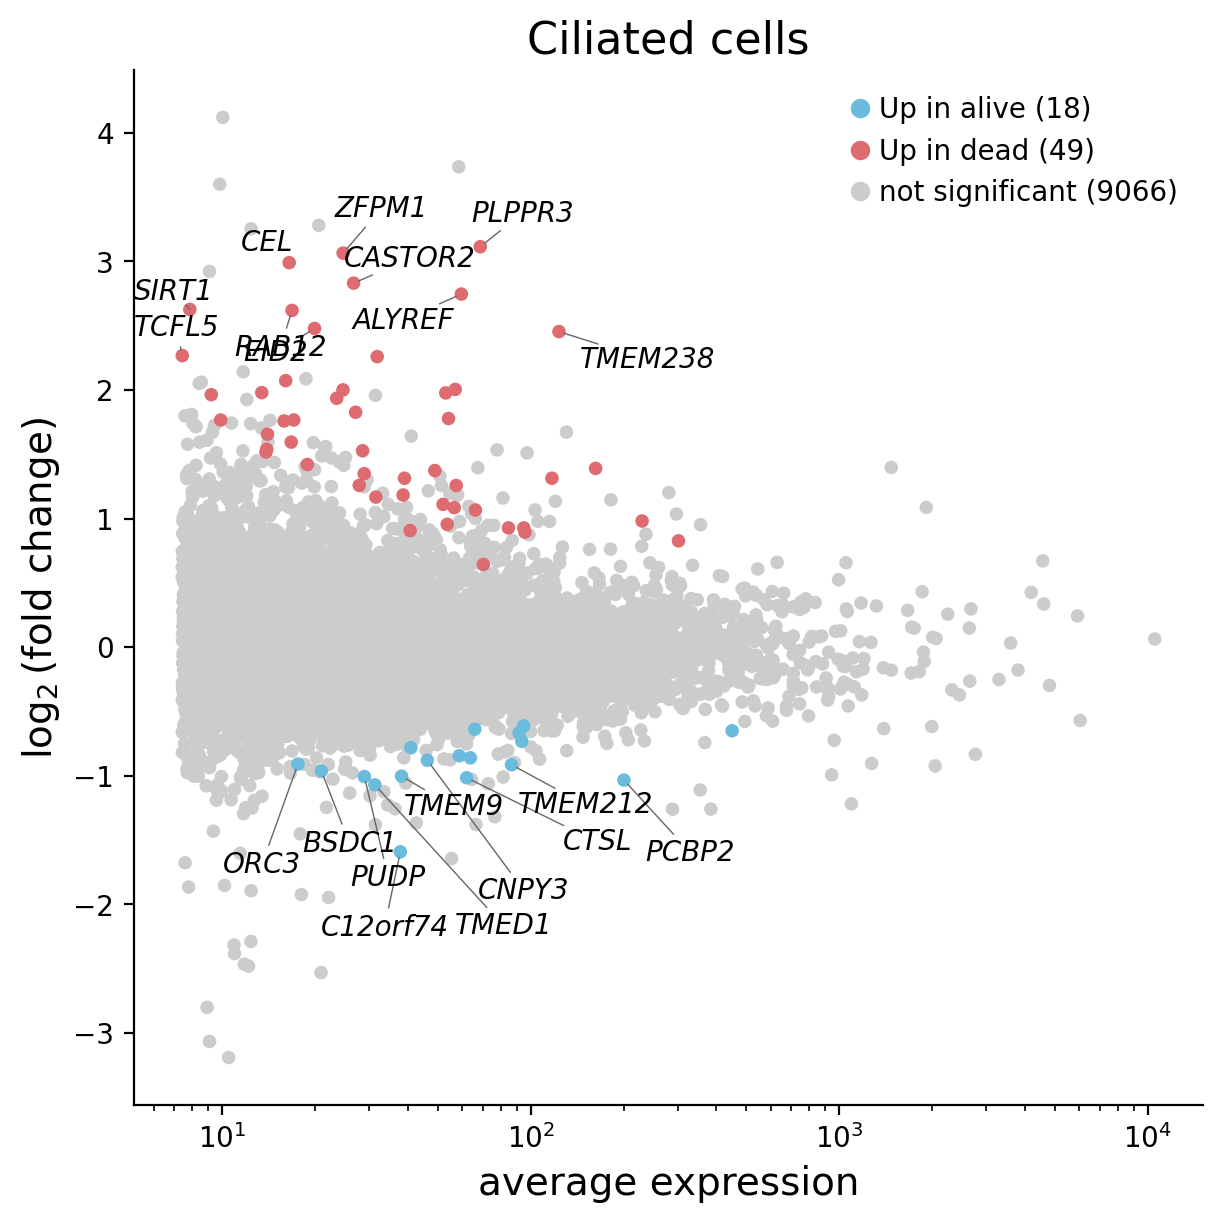

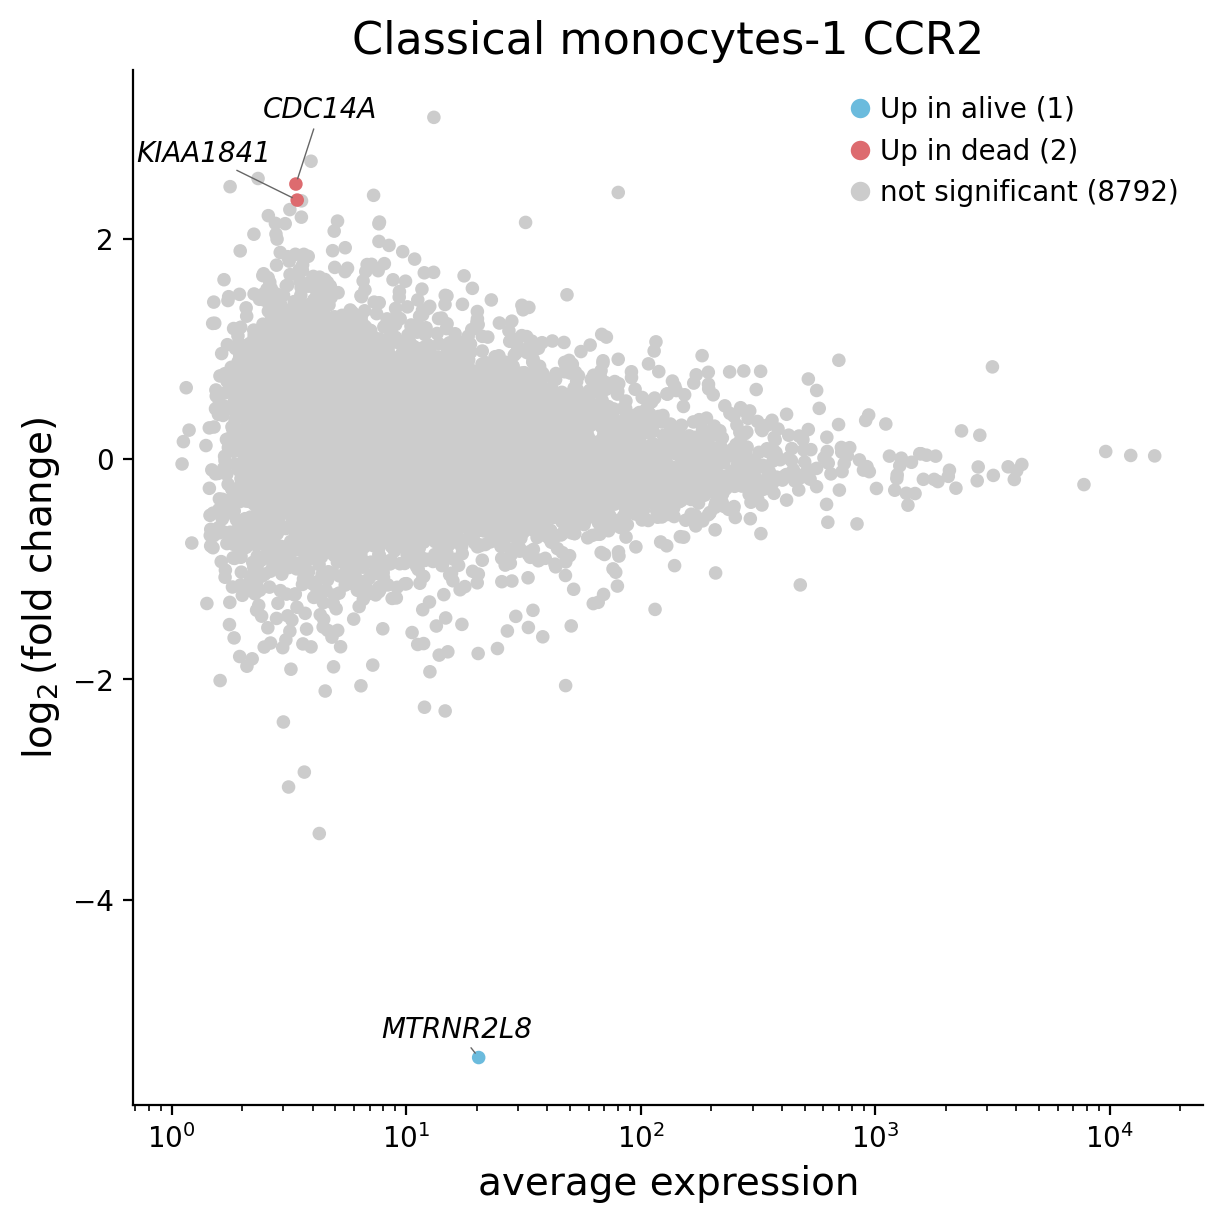

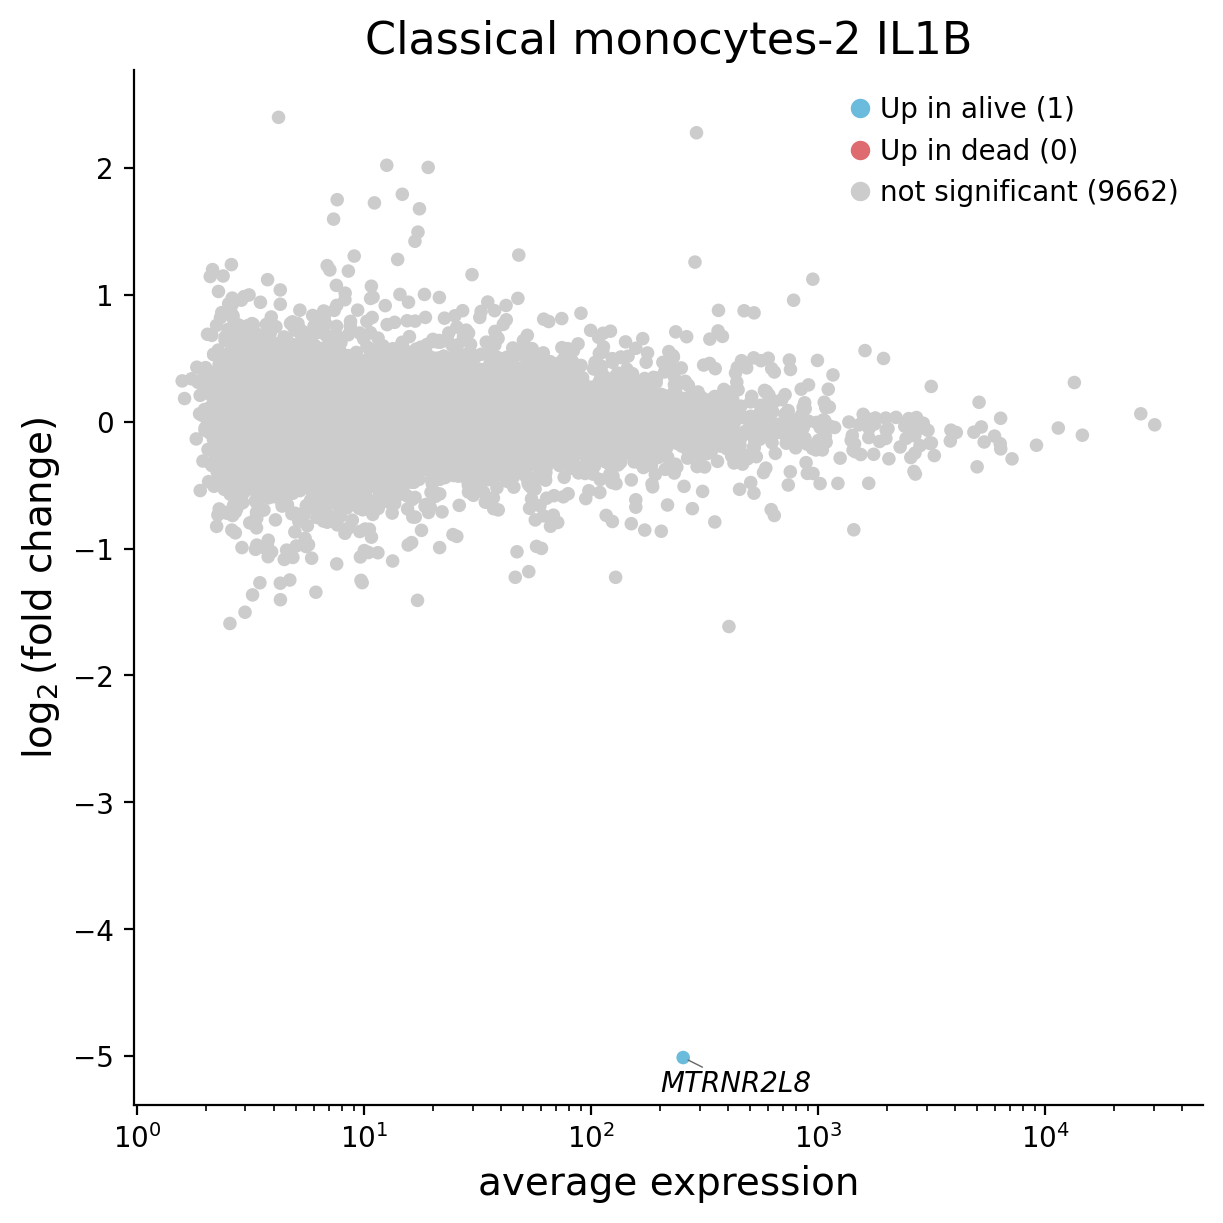

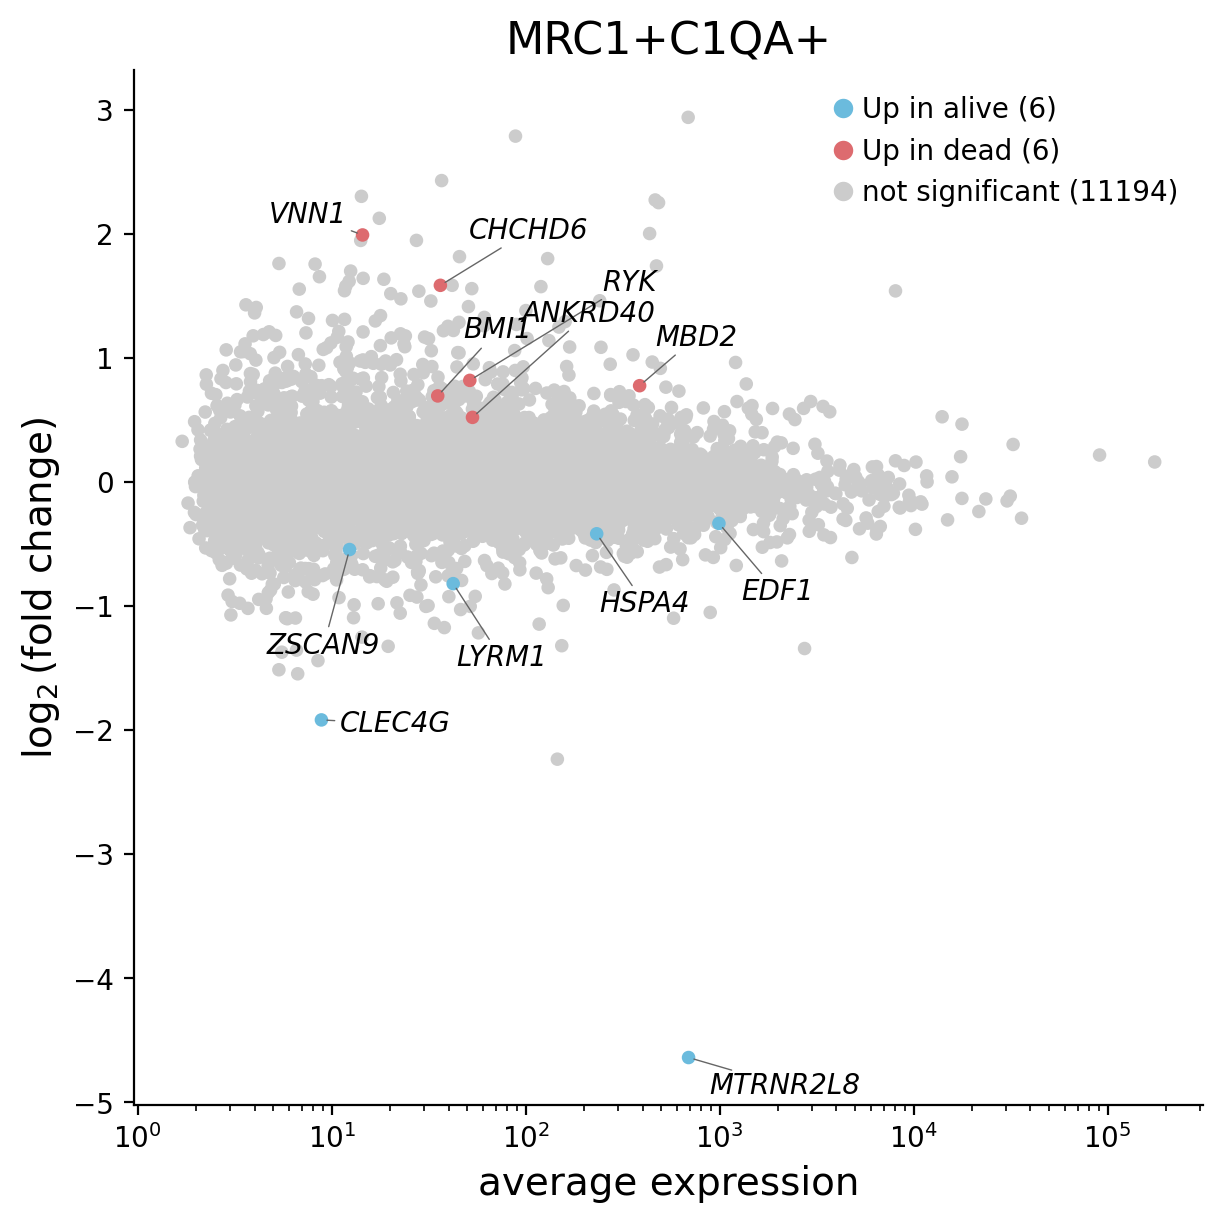

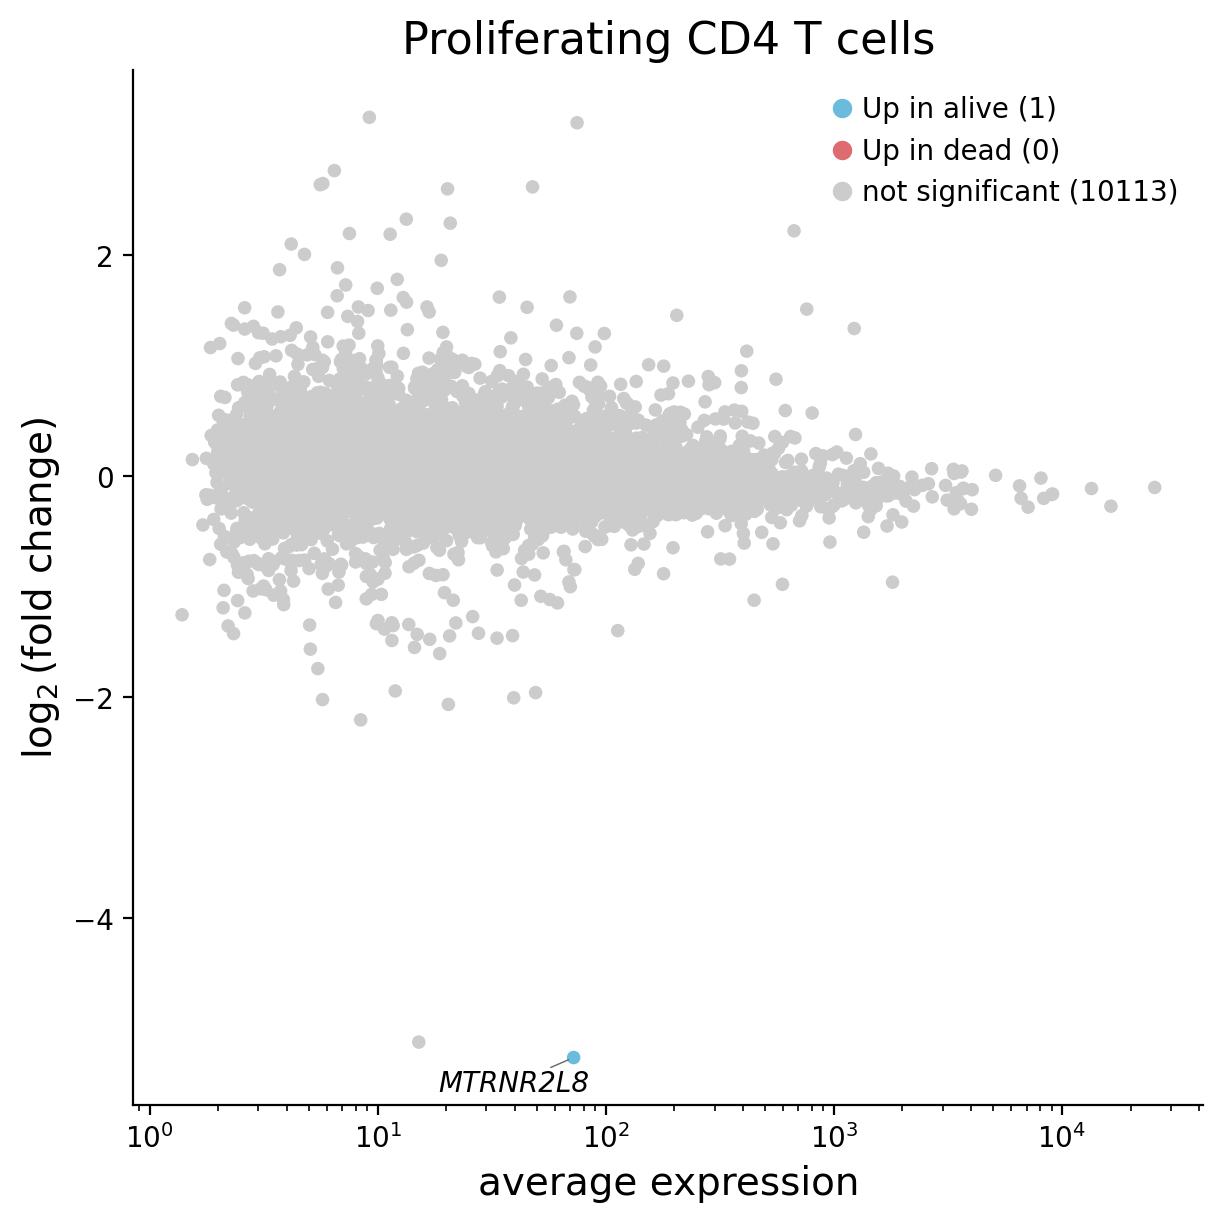

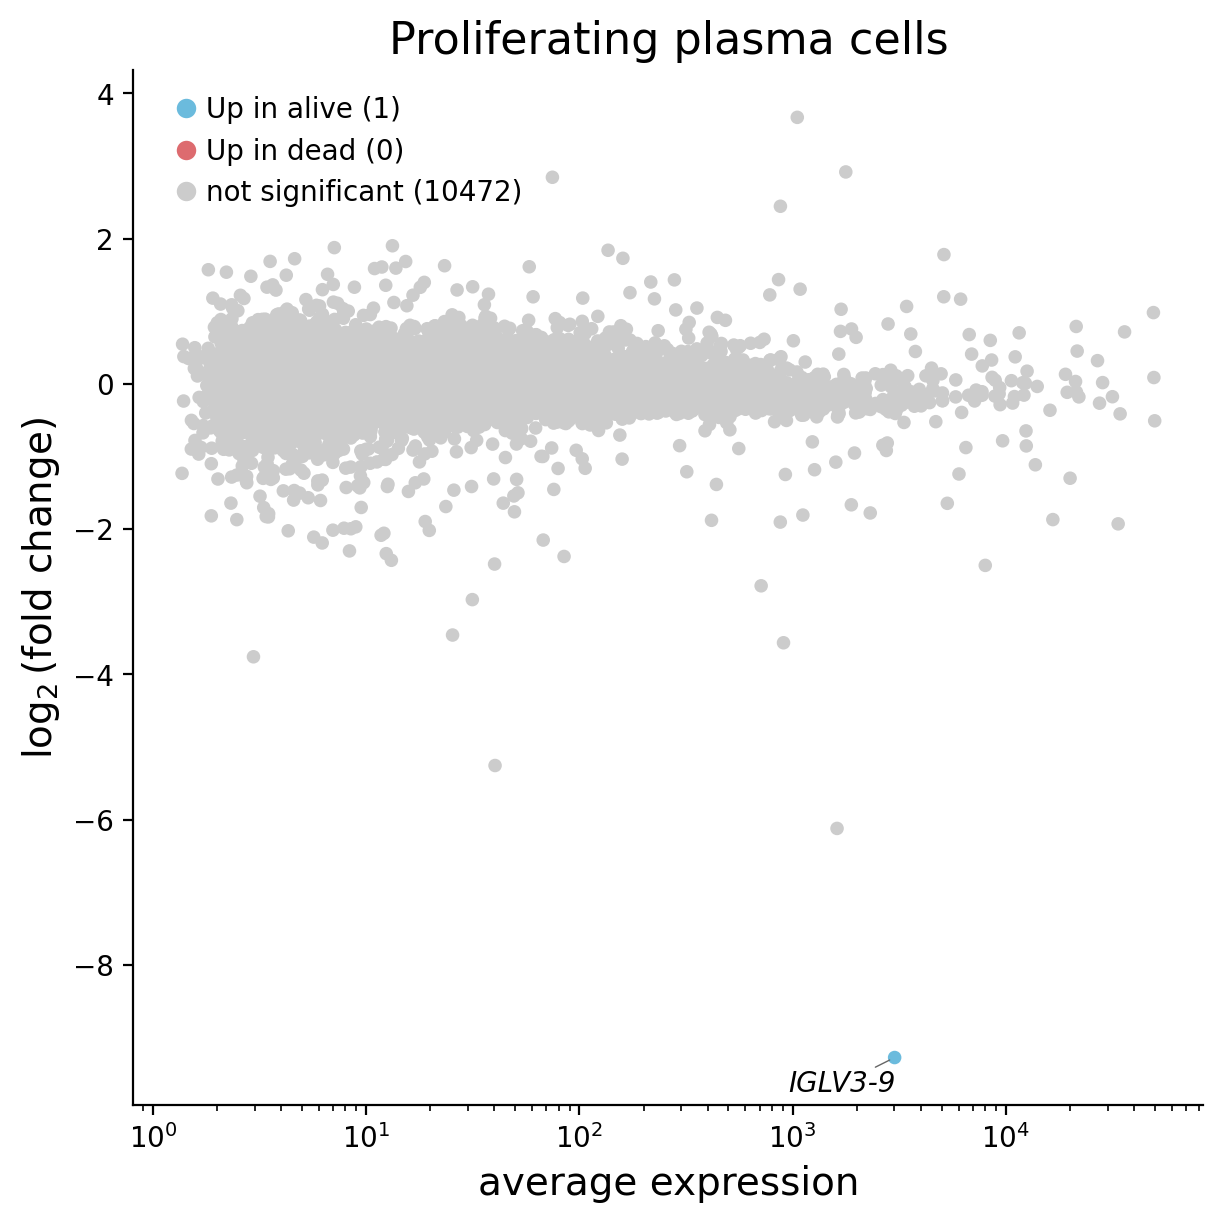

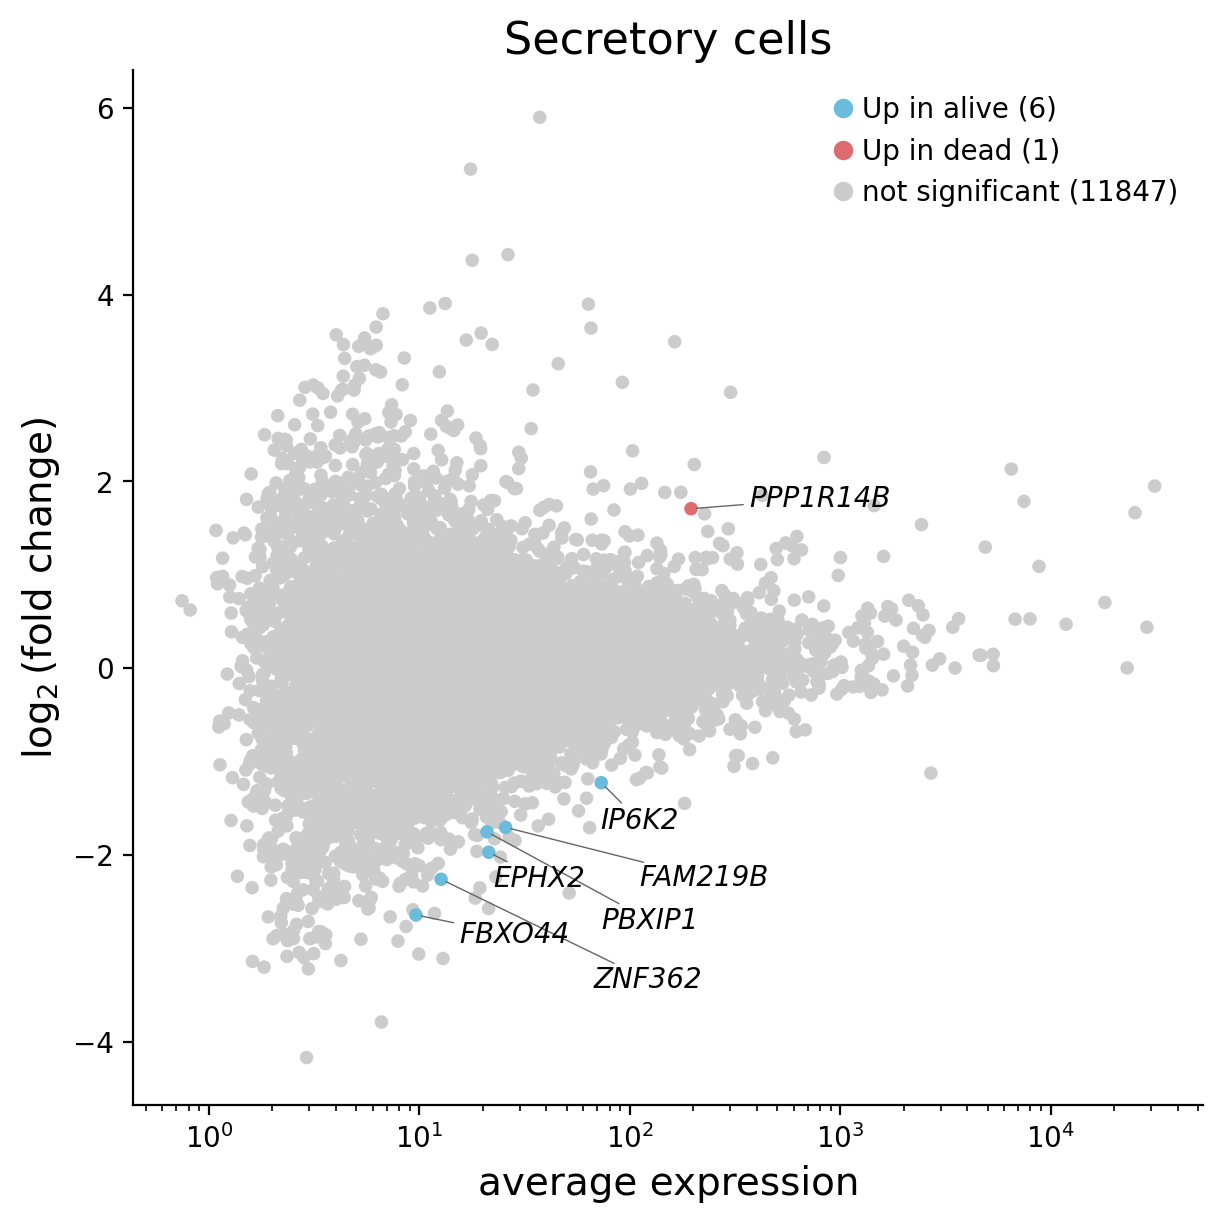

In [18]:
for ct in data['alive_vs_dead_viral'].info.values():
    if ct.comparisons[0].genes.sign.ne('').sum() < 1:
        continue
    plot_ma(
        ct.comparisons[0],
        ct.name,
        # adjust=False
    )
    plt.show()

In [ ]:
BASE = ROOT / '05_pseudobulk/20c_degs'

In [20]:
result = {}
for _, task in data.items():
    gseas = []
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        gsea_path = BASE / task.task_info.pathname / k / 'gsea.csv'
        if not gsea_path.exists():
            print(f'No GSEA for {k} in {task.task_info.pathname}')
            continue
        gsea = pd.read_csv(gsea_path, index_col=0)
        gsea['cell_type'] = k
        gseas.append(gsea)
    result[task.task_info.pathname] = pd.concat(gseas)

In [21]:
result.keys()

dict_keys(['alive_vs_dead_viral', 'alive_vs_dead_pathogen_negative', 'alive_vs_dead', 'alive_vs_dead_bacterial'])

In [22]:
def process_hallmark_name(name):
    short_words = ('ACID', 'VIA', 'BETA', 'LATE', 'BILE', 'HEME')
    result = []
    words = name.split('_')
    for word in words:
        if re.search(r'\d', word) or len(word) < 5 and word not in short_words:
            result.append(word)
        else:
            result.append(word.lower())
    result = ' '.join(result)
    result = result[0].capitalize() + result[1:]
    return result

In [23]:
def plot_gsea(task_info: common_data.TaskInfo, gsea: pd.DataFrame):
    gsea['p-value'] = gsea['NOM p-value'].copy()
    idx = gsea['p-value'].eq(0)
    min_p_val = gsea['p-value'][~idx].min()
    gsea.loc[idx, 'p-value'] = min_p_val * 0.01

    print(f'P-values exactly 0: {idx.sum()}')

    gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
    gsea['-log10(padj)'] = -np.log10(gsea.padj)
    gsea['-log10(padj)'] *= np.sign(gsea.NES)
    gsea_df = gsea.pivot_table(
        index='cell_type',
        columns='Term',
        values='-log10(padj)'
    )

    gsea_df_plot = gsea_df.fillna(0).T

    rownames = gsea_df.columns.str.replace('HALLMARK_', '')

    stars = np.empty_like(gsea_df_plot, dtype=str)
    stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

    cg = sns.clustermap(
        gsea_df_plot,
        method='ward',
        figsize=(12, 14),
        dendrogram_ratio=0.1,
        cbar_pos=(0.8, 0.82, 0.08, 0.02),
        cbar_kws=dict(
            label='$-log_{10}($q-value$) \\times sign(ES)$',
            orientation='horizontal'
        ),
        xticklabels=gsea_df.index,
        yticklabels=[process_hallmark_name(x) for x in rownames],
        cmap='coolwarm',
        annot=stars,
        fmt='',
        annot_kws=dict(
            va='center_baseline',
            fontsize=16
        )
    )
    cg.ax_cbar.annotate(task_info.column_values[0], (0, 1.3), xycoords='axes fraction', ha='left')
    cg.ax_cbar.annotate(task_info.column_values[1], (1, 1.3), xycoords='axes fraction', ha='right')

    cg.ax_heatmap.collections[0].set_rasterized(True)
    cg.ax_heatmap.set_xlabel('')
    cg.ax_heatmap.set_ylabel('')

    cg.ax_heatmap.set_xticklabels(
        cg.ax_heatmap.get_xticklabels(),
        fontsize=14,
        rotation=30,
        ha='right'
    )
    trans = mpl.transforms.Affine2D().translate(8, 0)
    for t in cg.ax_heatmap.get_xticklabels():
        t.set_transform(t.get_transform() + trans)

    cg.ax_heatmap.set_yticklabels(
        cg.ax_heatmap.get_yticklabels(),
        fontsize=14,
    )

    for t in cg.ax_heatmap.texts:
        if t.get_text() == '*':
            p = t.get_position()
            t.set_position((p[0], p[1] + 0.2))

    cg.ax_col_dendrogram.figure.subplots_adjust(left=0.05, bottom=0.1, top=1, right=0.73)
    cg.ax_cbar.set_position((0.76, 0.95, 0.15, 0.01))

    cg.ax_col_dendrogram.set_title(task_info.pathname)

    cg.ax_col_dendrogram.figure.savefig(f'00_plots/58_{task_info.pathname}_gsea.pdf', dpi=300)

Starting alive_vs_dead_viral
P-values exactly 0: 34
Starting alive_vs_dead_pathogen_negative
P-values exactly 0: 23
Starting alive_vs_dead
P-values exactly 0: 49
Starting alive_vs_dead_bacterial
P-values exactly 0: 27


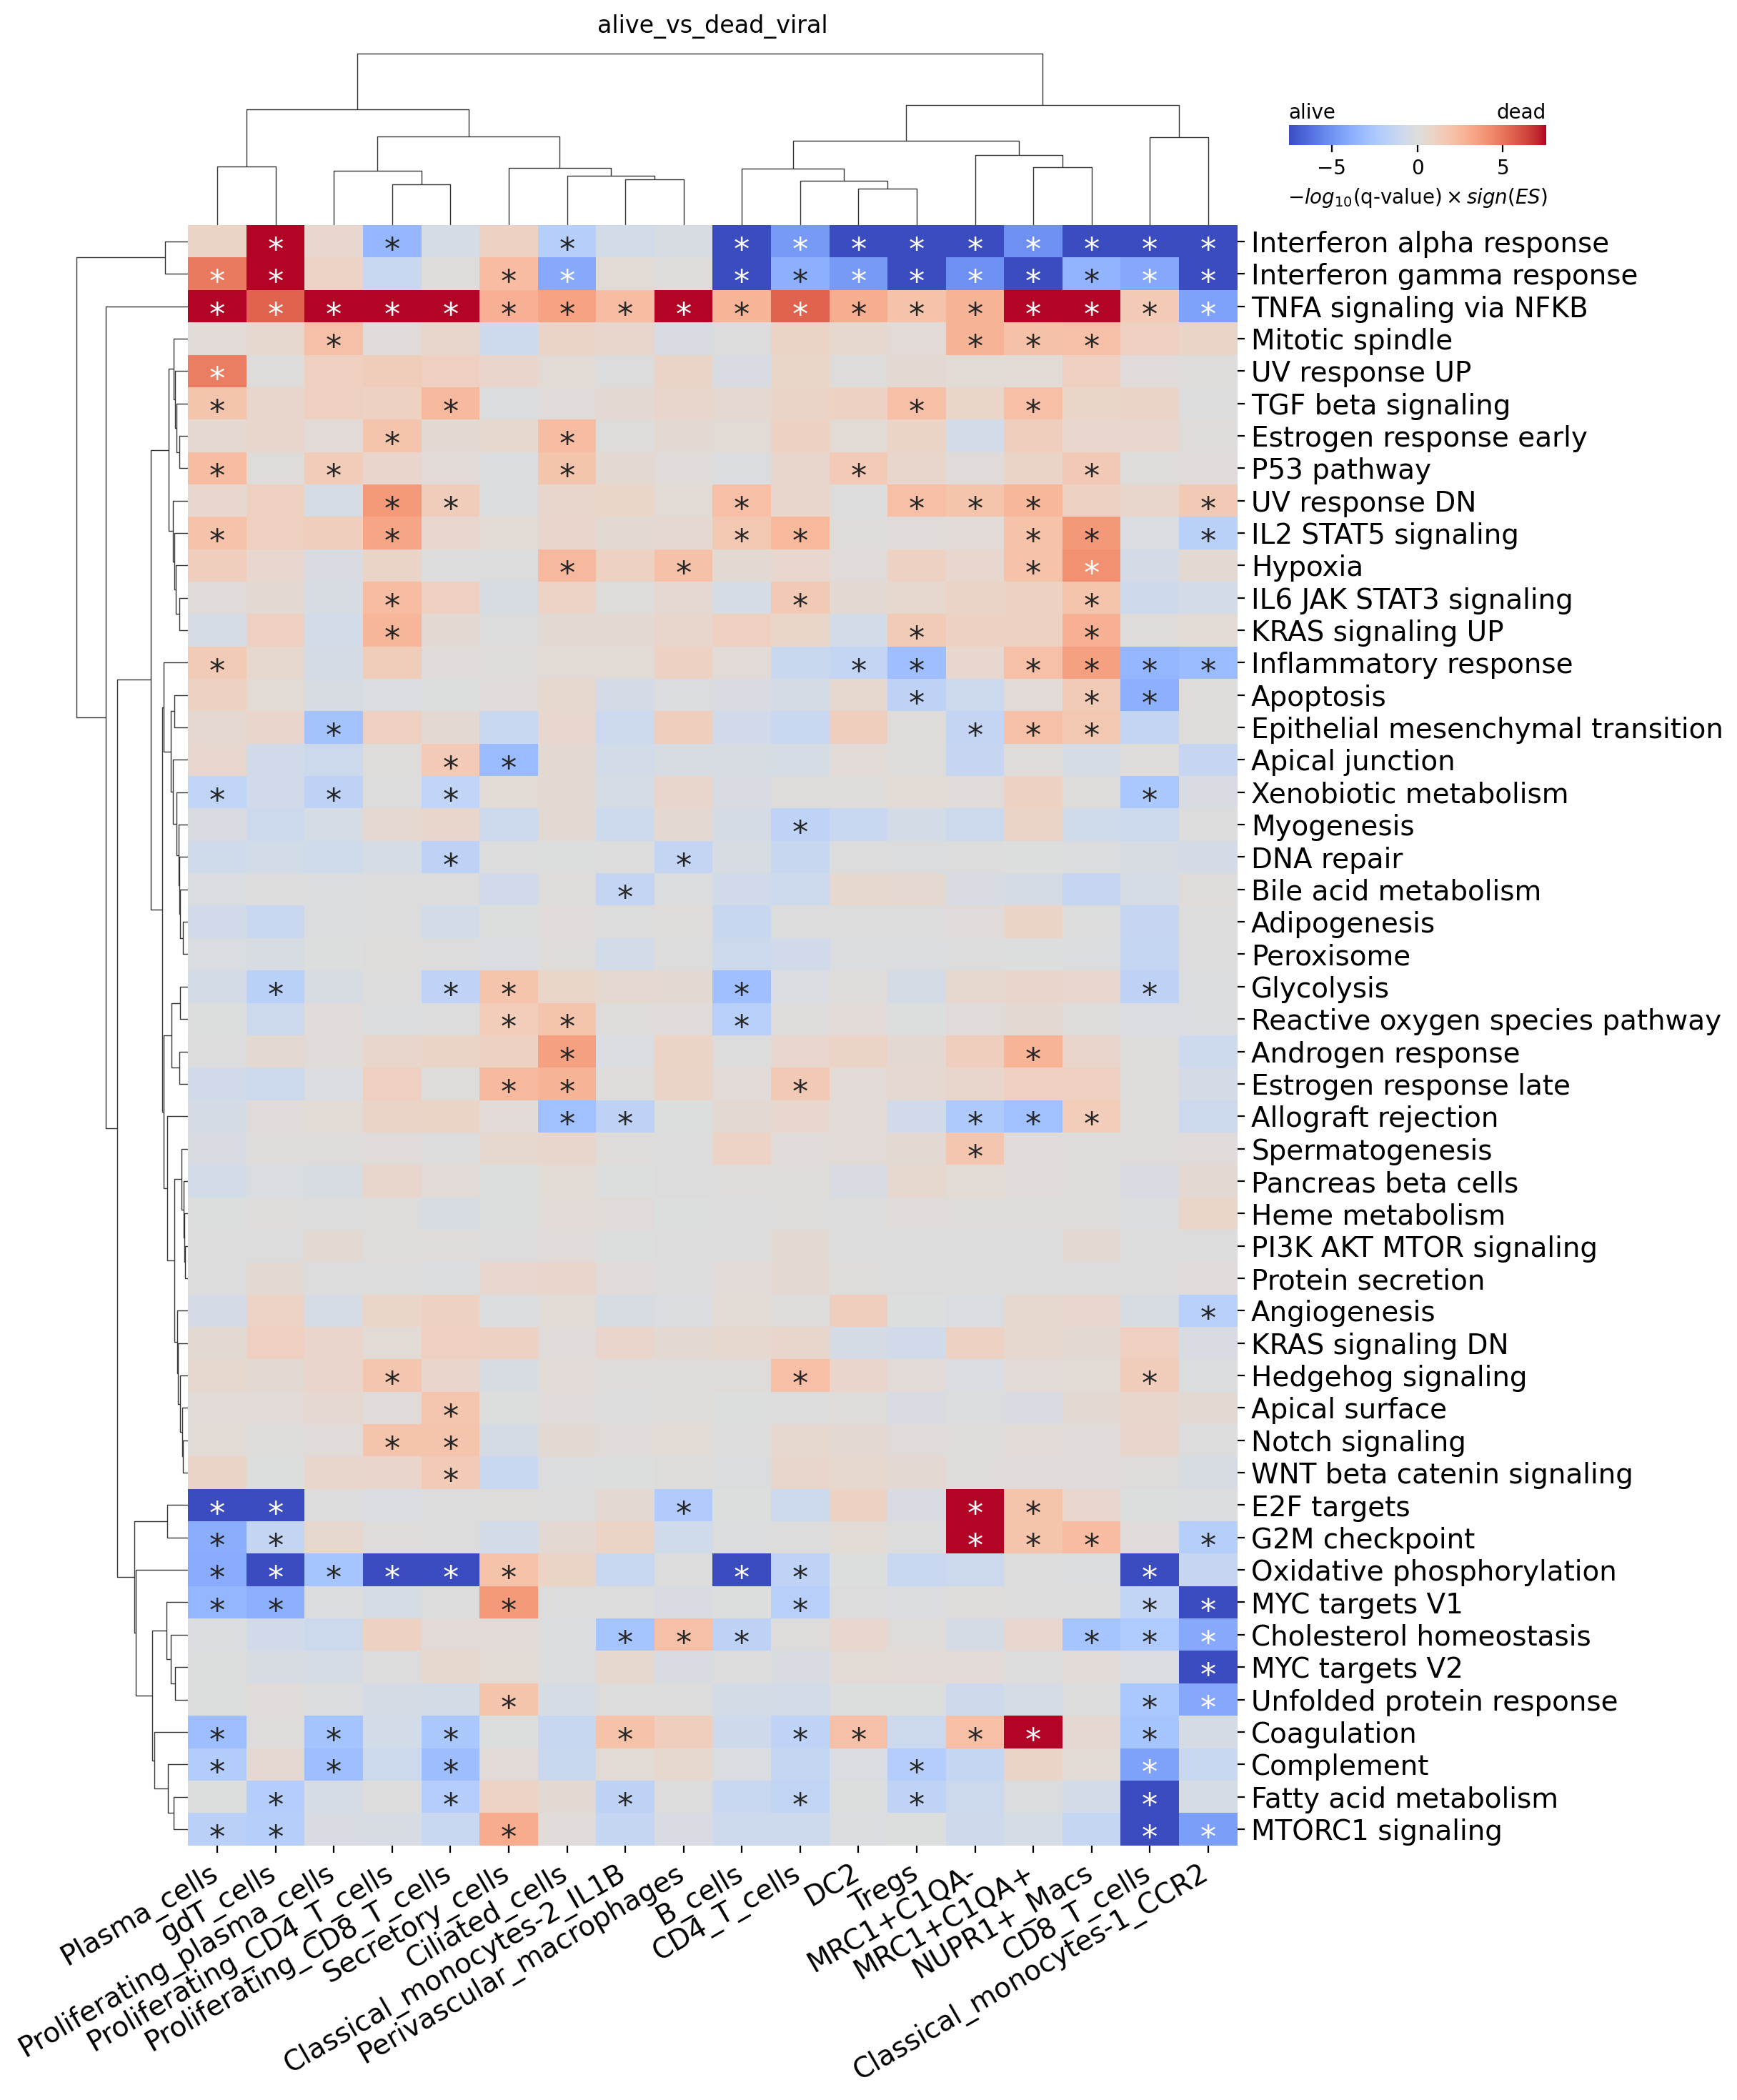

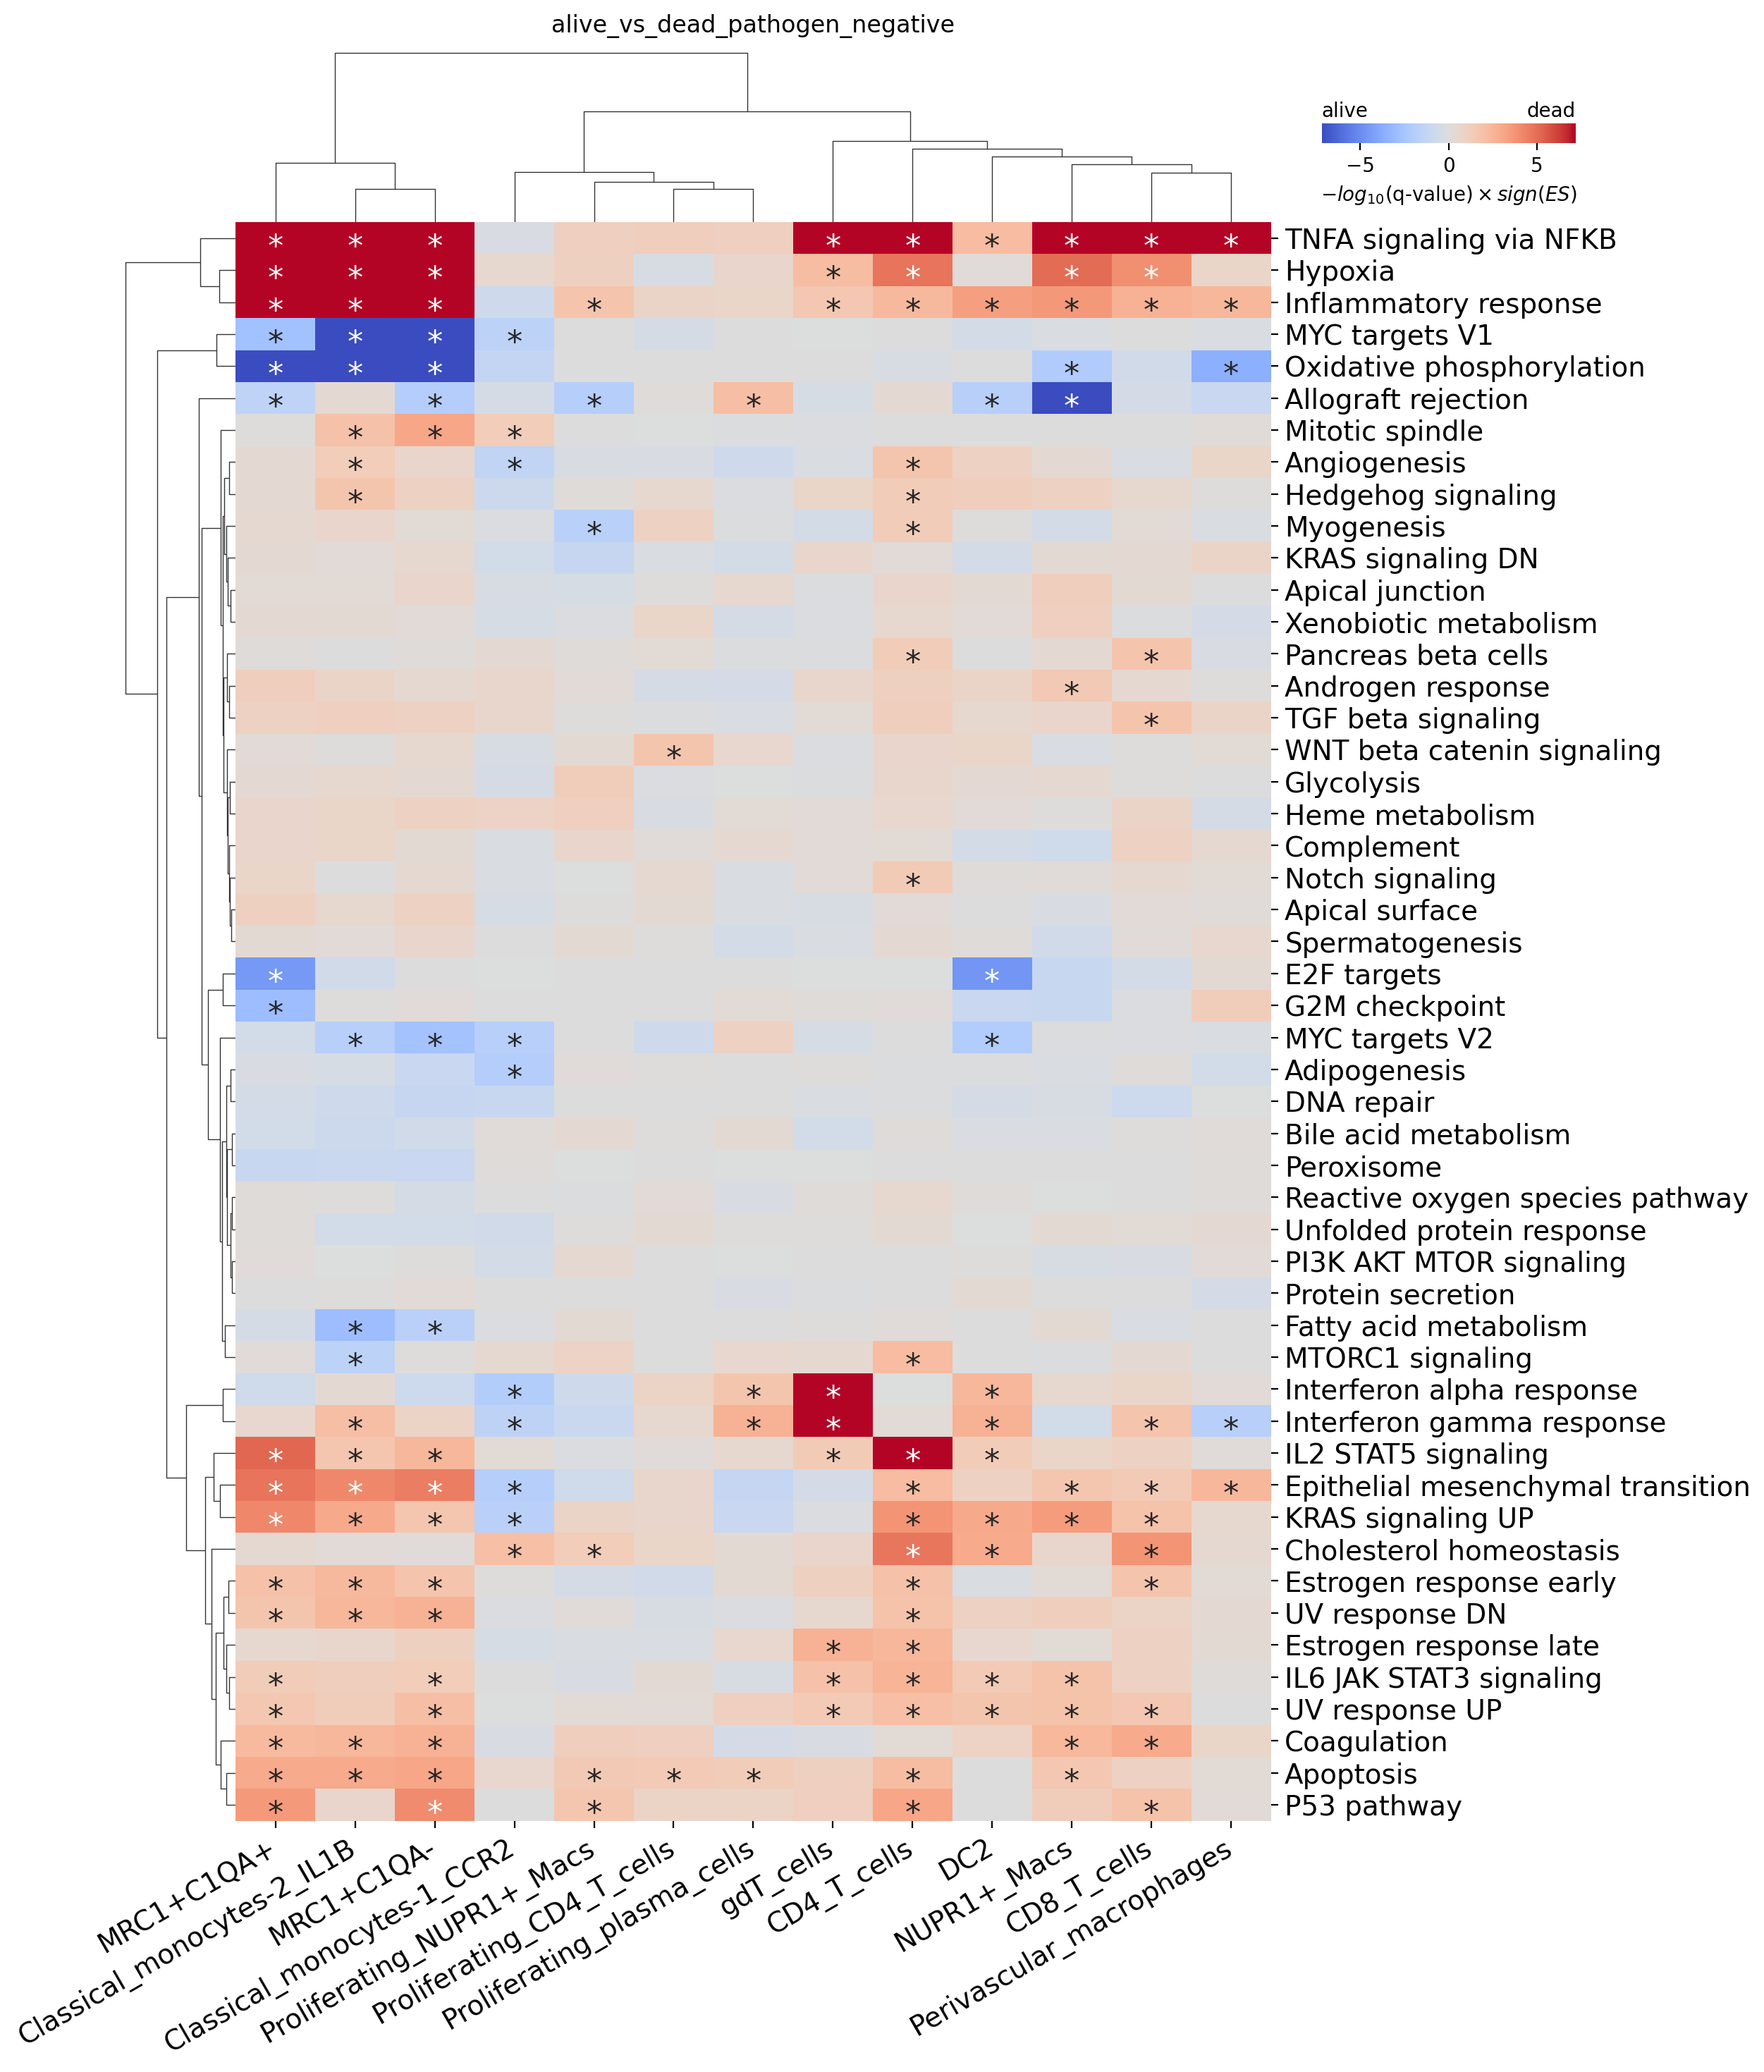

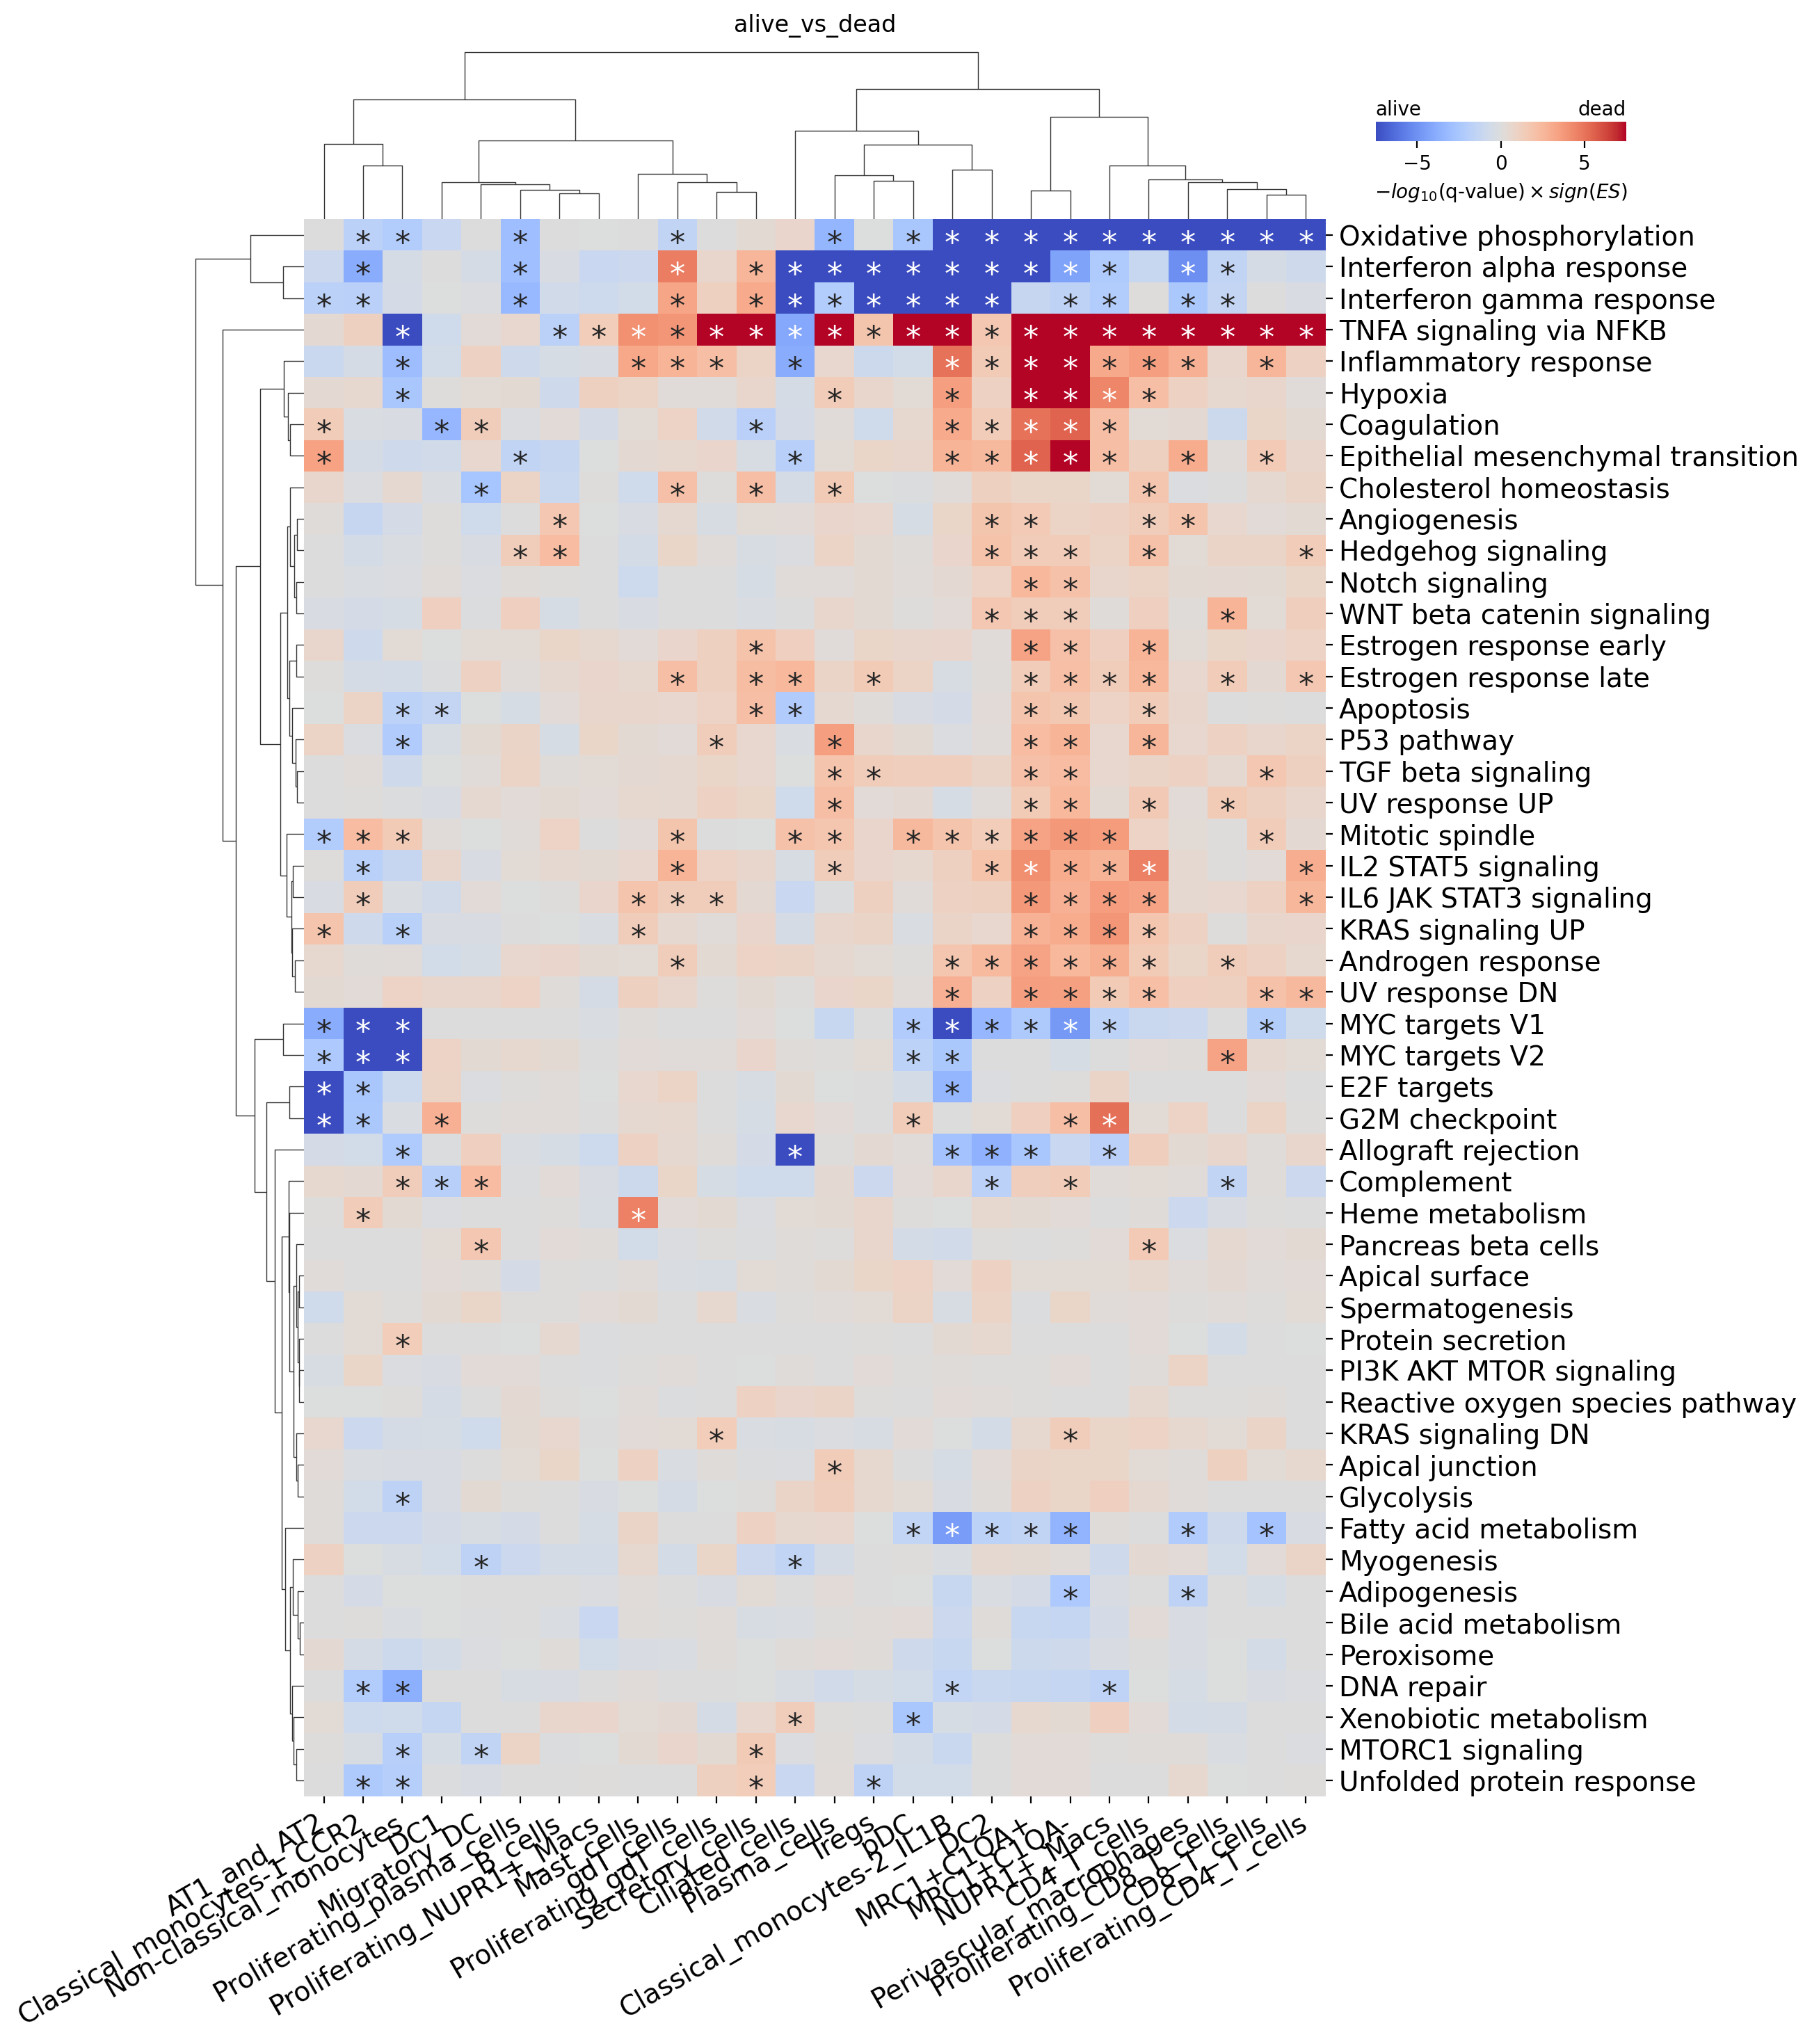

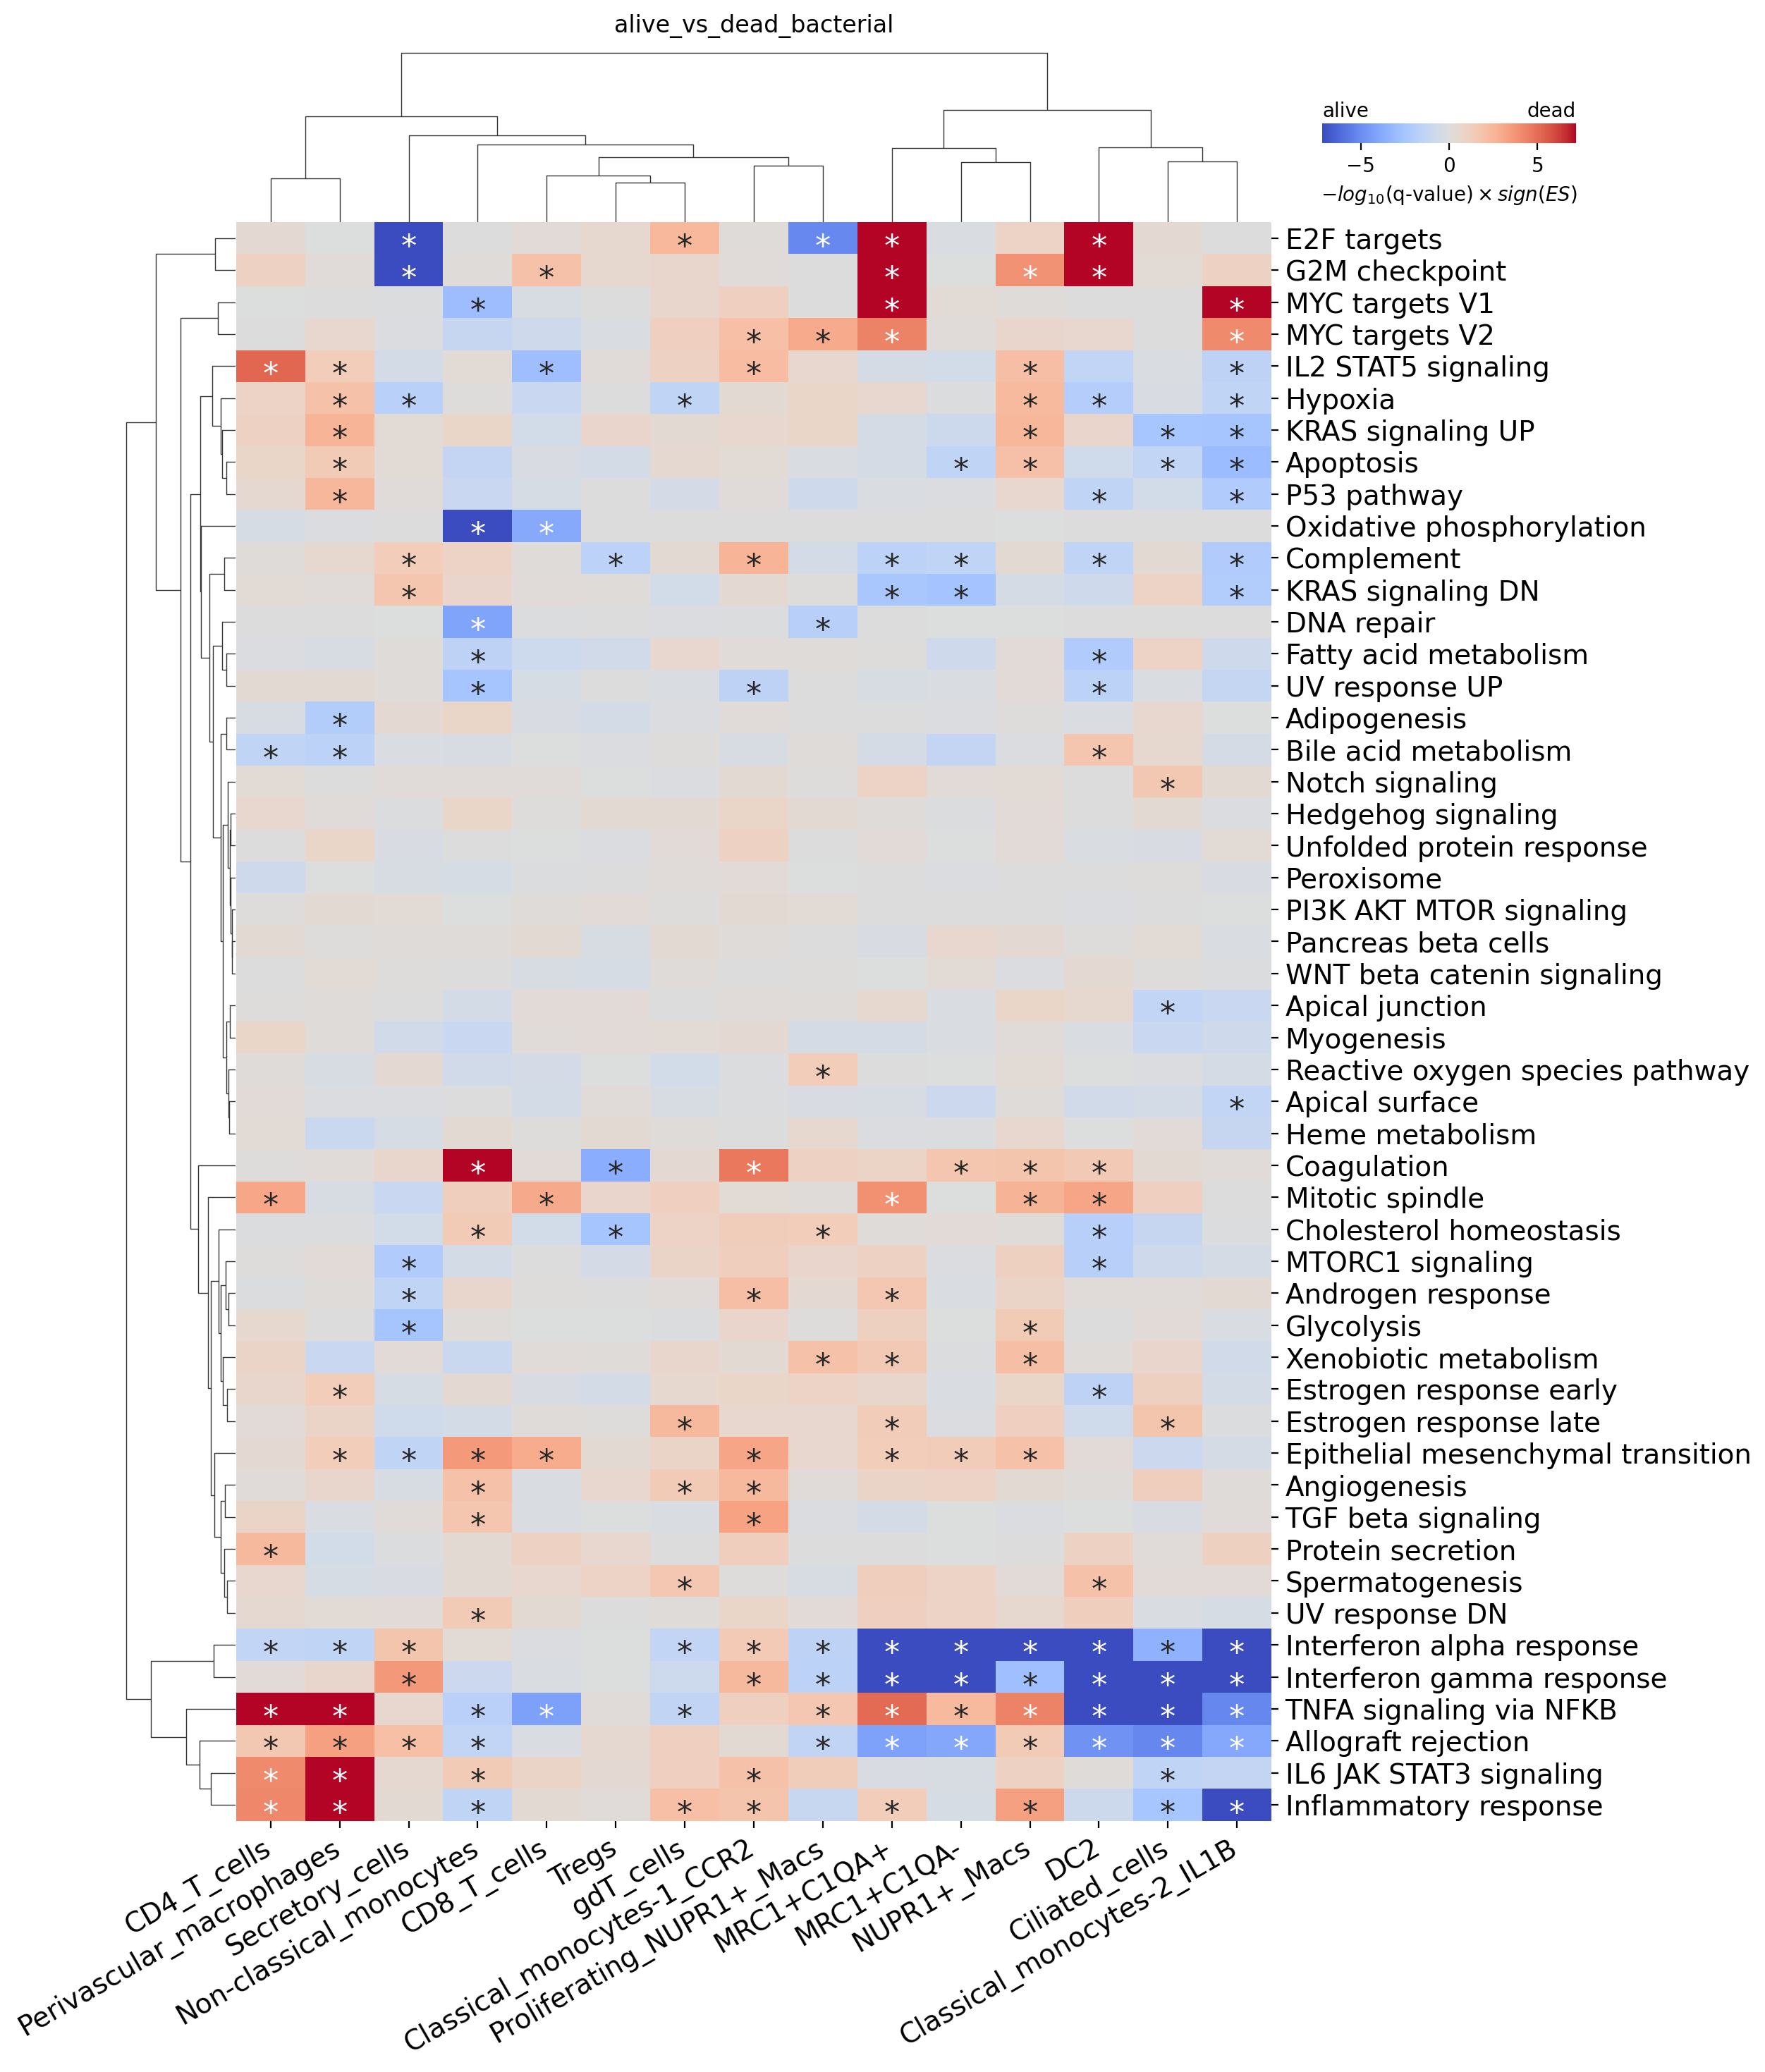

In [24]:
for d in data.values():
    print(f'Starting {d.task_info.pathname}')
    plot_gsea(d.task_info, result[d.task_info.pathname])

## Save for interactive exploration

In [25]:
n_degs_plot = pd.DataFrame()
n_degs = pd.DataFrame()
for task_data in data.values():
    for ct, info in task_data.info.items():
        name = task_data.task_info.pathname
        n_genes = info.comparisons[0].genes.padj.lt(PADJ_CUTOFF).sum()
        n_degs.loc[ct, name] = n_genes
        if n_genes > 0:
            n_genes = np.log10(n_genes)
        n_degs_plot.loc[ct, name] = n_genes
n_degs = n_degs.sort_index().T.sort_index()
n_degs_plot = n_degs_plot.sort_index().T.sort_index()

In [26]:
n_degs

,AT1_and_AT2,B_cells,CD4_T_cells,CD8_T_cells,Ciliated_cells,Classical_monocytes-1_CCR2,Classical_monocytes-2_IL1B,DC1,DC2,MRC1+C1QA+,MRC1+C1QA-,Mast_cells,Migratory_DC,NUPR1+_Macs,Non-classical_monocytes,Perivascular_macrophages,Plasma_cells,Proliferating_CD4_T_cells,Proliferating_CD8_T_cells,Proliferating_NUPR1+_Macs,Proliferating_gdT_cells,Proliferating_plasma_cells,Secretory_cells,Tregs,gdT_cells,pDC
alive_vs_dead,8.0,3.0,1206.0,2410.0,124.0,3.0,1832.0,0.0,212.0,2586.0,4197.0,2.0,0.0,2552.0,1.0,57.0,11.0,614.0,354.0,12.0,5.0,31.0,0.0,12.0,4.0,0.0
alive_vs_dead_bacterial,NaN,NaN,0.0,0.0,0.0,58.0,3.0,NaN,0.0,0.0,0.0,NaN,NaN,11.0,3.0,1.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,NaN
alive_vs_dead_pathogen_negative,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,7.0,NaN,NaN,1.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,3.0,NaN,NaN,0.0,NaN
alive_vs_dead_viral,NaN,1.0,4.0,0.0,67.0,3.0,1.0,NaN,0.0,12.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,1.0,0.0,NaN,NaN,1.0,7.0,0.0,0.0,NaN


In [ ]:
n_degs.to_csv('70_degs/20d_deg_counts.csv')

In [ ]:
for d in data.values():
    subdir = d.task_info.pathname
    gsea_path = f'70_degs/{subdir}_gsea.csv'
    gsea = result[d.task_info.pathname]
    gsea['p-value'] = gsea['NOM p-value'].copy()
    idx = gsea['p-value'].eq(0)
    min_p_val = gsea['p-value'][~idx].min()
    gsea.loc[idx, 'p-value'] = min_p_val * 0.01
    gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
    gsea['-log10(padj)'] = -np.log10(gsea.padj)
    gsea['-log10(padj)'] *= np.sign(gsea.NES)
    result[d.task_info.pathname].to_csv(gsea_path)

In [29]:
secretome = pd.read_table('protein_class_Predicted.tsv')

In [ ]:
for d in data.values():
    subdir = d.task_info.pathname
    for ct in d.info.keys():
        deg_path = f'70_degs/{subdir}/{ct}_degs.csv'
        degs = d.info[ct].comparisons[0].genes
        degs['secretome'] = pd.Series(degs.index.isin(secretome.Gene)).replace(
            {True: 'Yes', False: ''}
        ).values
        degs.sign = degs.sign.str.replace('Alive', 'alive').str.replace('Dead', 'dead')
        os.makedirs(os.path.dirname(deg_path), exist_ok=True)
        degs.to_csv(deg_path)

In [ ]:
result = []
for d in data.values():
    task_info = d.task_info
    group1 = task_info.column_values[0].lower()
    group2 = task_info.column_values[1].lower()
    for ct in d.info.keys():
        meta = d.info[ct].meta
        group1_count = meta.group.astype(str).eq('0').sum()
        group2_count = meta.group.astype(str).eq('1').sum()
        discard_count = meta.group.eq('discard').sum()
        group1_up = d.info[ct].comparisons[0].genes.sign.eq(f'Up in {group1}').sum()
        group2_up = d.info[ct].comparisons[0].genes.sign.eq(f'Up in {group2}').sum()
        result.append(
            {
                'cell_type': ct,
                'task': task_info.pathname,
                'group1': group1,
                'group2': group2,
                'group1_count': group1_count,
                'group2_count': group2_count,
                'discard_count': discard_count,
                'group1_up': group1_up,
                'group2_up': group2_up
            }
        )
result = pd.DataFrame(result)
result.to_csv('70_degs/20d_deg_stats.csv')

In [32]:
result

,cell_type,task,group1,group2,group1_count,group2_count,discard_count,group1_up,group2_up
0,B_cells,alive_vs_dead_viral,alive,dead,3,3,54,1,0
1,CD4_T_cells,alive_vs_dead_viral,alive,dead,14,17,235,1,3
2,CD8_T_cells,alive_vs_dead_viral,alive,dead,14,18,246,0,0
3,Ciliated_cells,alive_vs_dead_viral,alive,dead,5,6,59,18,49
4,Classical_monocytes-1_CCR2,alive_vs_dead_viral,alive,dead,5,6,78,1,2
5,Classical_monocytes-2_IL1B,alive_vs_dead_viral,alive,dead,13,16,209,1,0
6,DC2,alive_vs_dead_viral,alive,dead,11,6,151,0,0
7,MRC1+C1QA+,alive_vs_dead_viral,alive,dead,17,18,261,6,6
8,MRC1+C1QA-,alive_vs_dead_viral,alive,dead,17,18,263,0,0
9,NUPR1+_Macs,alive_vs_dead_viral,alive,dead,16,18,233,0,0
